In [38]:
import pandas as pd
import numpy as np
import glob
from scipy.io import loadmat
import joblib
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from enigmatoolbox.plotting import plot_subcortical
print("ENIGMA Toolbox installed correctly!")


ENIGMA Toolbox installed correctly!


In [39]:
import re

files = np.sort(glob.glob("./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat"))
fc = {}
for f in files:
    tmp = loadmat(f)['subj_final_corr_mat']
    # Extract participant ID using regex
    match = re.search(r"sub-(\d+)_", f)
    if match:
        pid = match.group(1)
        fc[pid] = tmp
    else:
        print(f"Could not extract participant ID from {f}")
print(f"Total files loaded: {len(fc)}")

Total files loaded: 187


# Load demographics

In [40]:
# --- Robust demographics and FC matching ---
# Load main demographics CSV and ensure participant_id is string and cleaned
demo = pd.read_csv('./BD-SCZ/participants_HC_SCZ_BD.csv', header=1)
demo['participant_id'] = demo['participant_id'].astype(str).str.strip().str.upper()
print('Raw demo IDs:', demo['participant_id'].tolist())
# Extract numeric ID from demo to match FC keys (e.g., 'SUB-10159' -> '10159')
demo['participant_id_num'] = demo['participant_id'].str.extract(r'(\d+)$')[0]
print('Numeric demo IDs:', demo['participant_id_num'].tolist())
# FC keys are already numeric strings, print for debug
print('FC keys:', list(fc.keys()))
# Merge demo with FC keys to keep only subjects with FC data
id_df = pd.DataFrame({'participant_id_num': list(fc.keys())})
demo_merged = pd.merge(id_df, demo, on='participant_id_num', how='inner')
print('Merged demo shape:', demo_merged.shape)
print('Merged demo IDs:', demo_merged['participant_id_num'].tolist())
# Load clinical data and merge
clinc_bd = pd.read_excel('./BD-SCZ/Demographics BD.xlsx')
clinc_scz = pd.read_excel('./BD-SCZ/Demographics SCZ.xlsx')
clinic = pd.concat([clinc_bd[['participant_id'] + list(clinc_bd.columns[5:])],
                    clinc_scz[['participant_id'] + list(clinc_scz.columns[5:])]],
                    axis=0,ignore_index=True)
clinic['participant_id'] = clinic['participant_id'].astype(str).str.strip().str.upper()
clinic['participant_id_num'] = clinic['participant_id'].str.extract(r'(\d+)$')[0]
demo_merged = pd.merge(demo_merged, clinic, on='participant_id_num', how='left')
print('Final merged demo shape:', demo_merged.shape)
print('Final merged demo columns:', demo_merged.columns.tolist())
# Standardize diagnosis and gender columns
demo_merged['diagnosis'] = demo_merged['diagnosis'].replace({'CONTROL': 1, 'SCHZ': 2, 'BIPOLAR': 3})
demo_merged['diagnosis2'] = np.array(demo_merged['diagnosis'])
demo_merged.loc[demo_merged['diagnosis2'] == 3, 'diagnosis2'] = 2
demo_merged['gender'] = demo_merged['gender'].replace({'M': 1, 'F': 2})
print('Diagnosis values:', demo_merged['diagnosis'].unique())
print('Gender values:', demo_merged['gender'].unique())
# --- Group FC extraction ---
# Group FC: first 400 parcels
fc_CTR      = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1] if i in fc])
fc_SCZ      = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2] if i in fc])
fc_BD       = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3] if i in fc])
fc_mix      = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1] if i in fc])
print('fc_CTR shape (400 parcels):', fc_CTR.shape)
print('fc_SCZ shape (400 parcels):', fc_SCZ.shape)
print('fc_BD shape (400 parcels):', fc_BD.shape)
print('fc_mix shape (400 parcels):', fc_mix.shape)
# Group FC: full parcel matrices
fc_CTR_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1] if i in fc])
fc_SCZ_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2] if i in fc])
fc_BD_full  = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3] if i in fc])
fc_mix_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1] if i in fc])
print('fc_CTR_full shape (all parcels):', fc_CTR_full.shape)
print('fc_SCZ_full shape (all parcels):', fc_SCZ_full.shape)
print('fc_BD_full shape (all parcels):', fc_BD_full.shape)
print('fc_mix_full shape (all parcels):', fc_mix_full.shape)
# Use demo_merged for all downstream analysis
demo = demo_merged.copy()

Raw demo IDs: ['SUB-10159', 'SUB-10171', 'SUB-10189', 'SUB-10193', 'SUB-10206', 'SUB-10217', 'SUB-10225', 'SUB-10227', 'SUB-10228', 'SUB-10235', 'SUB-10249', 'SUB-10269', 'SUB-10271', 'SUB-10273', 'SUB-10274', 'SUB-10280', 'SUB-10290', 'SUB-10292', 'SUB-10299', 'SUB-10304', 'SUB-10316', 'SUB-10321', 'SUB-10325', 'SUB-10329', 'SUB-10339', 'SUB-10340', 'SUB-10345', 'SUB-10347', 'SUB-10356', 'SUB-10361', 'SUB-10365', 'SUB-10376', 'SUB-10377', 'SUB-10388', 'SUB-10428', 'SUB-10429', 'SUB-10438', 'SUB-10440', 'SUB-10448', 'SUB-10455', 'SUB-10460', 'SUB-10471', 'SUB-10478', 'SUB-10487', 'SUB-10492', 'SUB-10501', 'SUB-10506', 'SUB-10517', 'SUB-10523', 'SUB-10524', 'SUB-10525', 'SUB-10527', 'SUB-10530', 'SUB-10557', 'SUB-10565', 'SUB-10570', 'SUB-10575', 'SUB-10624', 'SUB-10629', 'SUB-10631', 'SUB-10638', 'SUB-10668', 'SUB-10672', 'SUB-10674', 'SUB-10678', 'SUB-10680', 'SUB-10686', 'SUB-10692', 'SUB-10696', 'SUB-10697', 'SUB-10704', 'SUB-10707', 'SUB-10708', 'SUB-10719', 'SUB-10724', 'SUB-10746

## Group-average functional connectivity (FC) matrix between 14 subcortical regions and 400 cortical parcels.

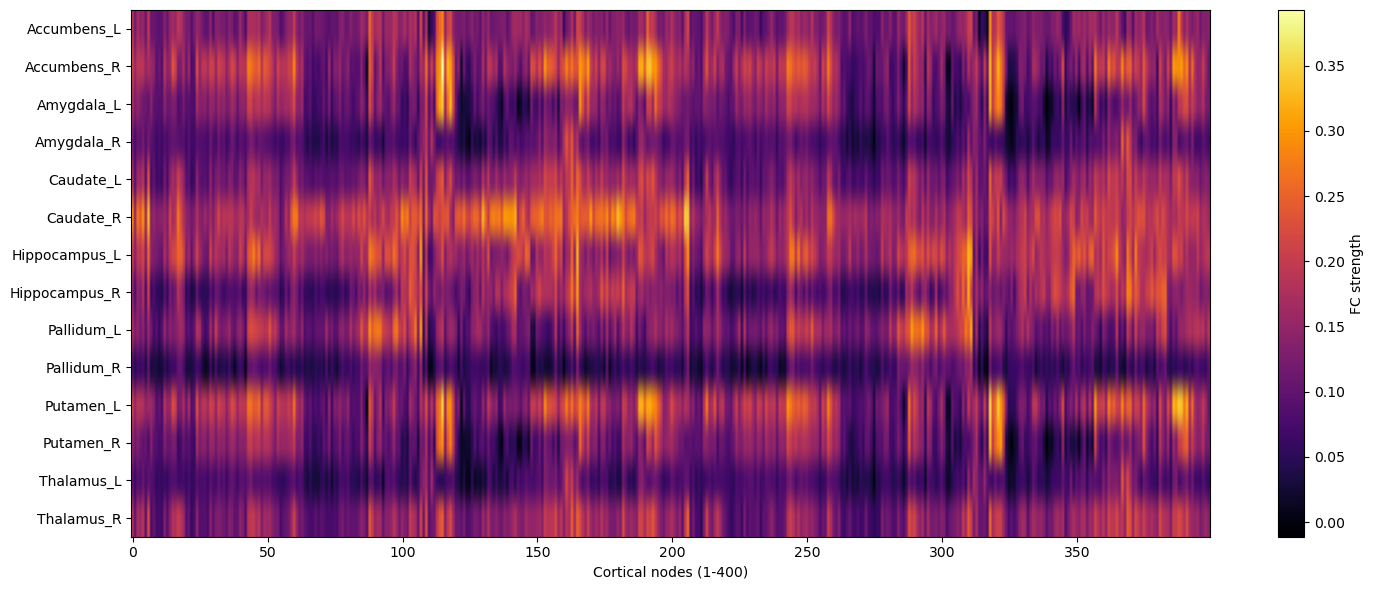

In [41]:
import numpy as np
import matplotlib.pyplot as plt
all_subjects = demo['participant_id_num'].tolist()
fc_full_list = [fc[i] for i in all_subjects if i in fc]
# Compute group-average subcortical-to-cortex FC
# fc_full_list already contains subject FC matrices
subcort_to_cortex = np.array([fc[-14:, :400] for fc in fc_full_list])  # shape: n_subjects x 14 x 400
mean_fc_matrix = subcort_to_cortex.mean(axis=0)  # average across subjects, shape 14 x 400

# Subcortical labels for plotting
subcort_labels = [
    'Accumbens_L', 'Accumbens_R', 'Amygdala_L', 'Amygdala_R',
    'Caudate_L', 'Caudate_R', 'Hippocampus_L', 'Hippocampus_R',
    'Pallidum_L', 'Pallidum_R', 'Putamen_L', 'Putamen_R',
    'Thalamus_L', 'Thalamus_R'
]

# Plot the mean FC matrix
plt.figure(figsize=(15,6))
im = plt.imshow(mean_fc_matrix, aspect='auto', cmap='inferno')
plt.yticks(range(len(subcort_labels)), subcort_labels)
plt.xlabel('Cortical nodes (1-400)')
plt.tight_layout()
plt.colorbar(im, label='FC strength')

# Save figure
plt.savefig('./new_figures/subcortical_fc_matrix.png', dpi=300)
plt.show()


# Gradient 1 embedding
“Does this region connect more to the low-gradient cortical areas or the high-gradient areas?”

The Pearson correlation quantifies this.

In [42]:
# --- Load aligned G2 gradient CSV (used in PLS) ---
# Rows = subjects, columns = metadata + nodes
g1_aligned = pd.read_csv("./g1_aligned_cog_updated.csv", index_col=0)

# --- Extract cortical parcel columns only ---
parcel_cols_g1 = [f"node_{i+1}" for i in range(400)]
g1_nodes = g1_aligned[parcel_cols_g1]

# --- Compute group-average gradient (length 400) ---
gradient_vec_g1 = g1_nodes.mean(axis=0).to_numpy()
print("G2 gradient vector shape:", gradient_vec_g1.shape)  # should be (400,)

# --- Function to compute subcortical embeddings with positive FC threshold ---
def compute_subcortical_embedding_corr_g1(fc_group_full, gradient_vec_g1):
    results_g1 = []
    for subj_fc in fc_group_full:
        # Threshold FC to keep only positive values
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)
        Ci_j_g1 = subj_fc_thr[-14:, :400]  # subcortex-to-cortex
        subj_vals_g1 = [pearsonr(Ci_j_g1[i, :], gradient_vec_g1)[0] for i in range(14)]
        results_g1.append(subj_vals_g1)
    return np.array(results_g1)

# --- Compute embeddings for all subjects ---
all_subjects_g1 = demo['participant_id_num'].tolist()
fc_full_list_g1 = [fc[i] for i in all_subjects_g1 if i in fc]

embeddings_g1 = compute_subcortical_embedding_corr_g1(fc_full_list_g1, gradient_vec_g1)

# --- Build DataFrame matching demo structure ---
subcort_regions_g1 = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

subcort_df_g1 = pd.DataFrame(embeddings_g1, columns=subcort_regions_g1)

# Keep the demo info
demo_subcort_g1 = demo.loc[demo['participant_id_num'].isin(all_subjects_g1)].copy()
demo_subcort_g1 = demo_subcort_g1.reset_index(drop=True)

# Merge embeddings with demographic info
demo_subcort_g1 = pd.concat([demo_subcort_g1, subcort_df_g1], axis=1)

# --- Save to CSV ---
demo_subcort_g1.to_csv('./g1_subcortical_embedding_corr_demo.csv', index=False)
print("Saved G1 subcortical embedding CSV with demographics!")

G2 gradient vector shape: (400,)
Saved G1 subcortical embedding CSV with demographics!


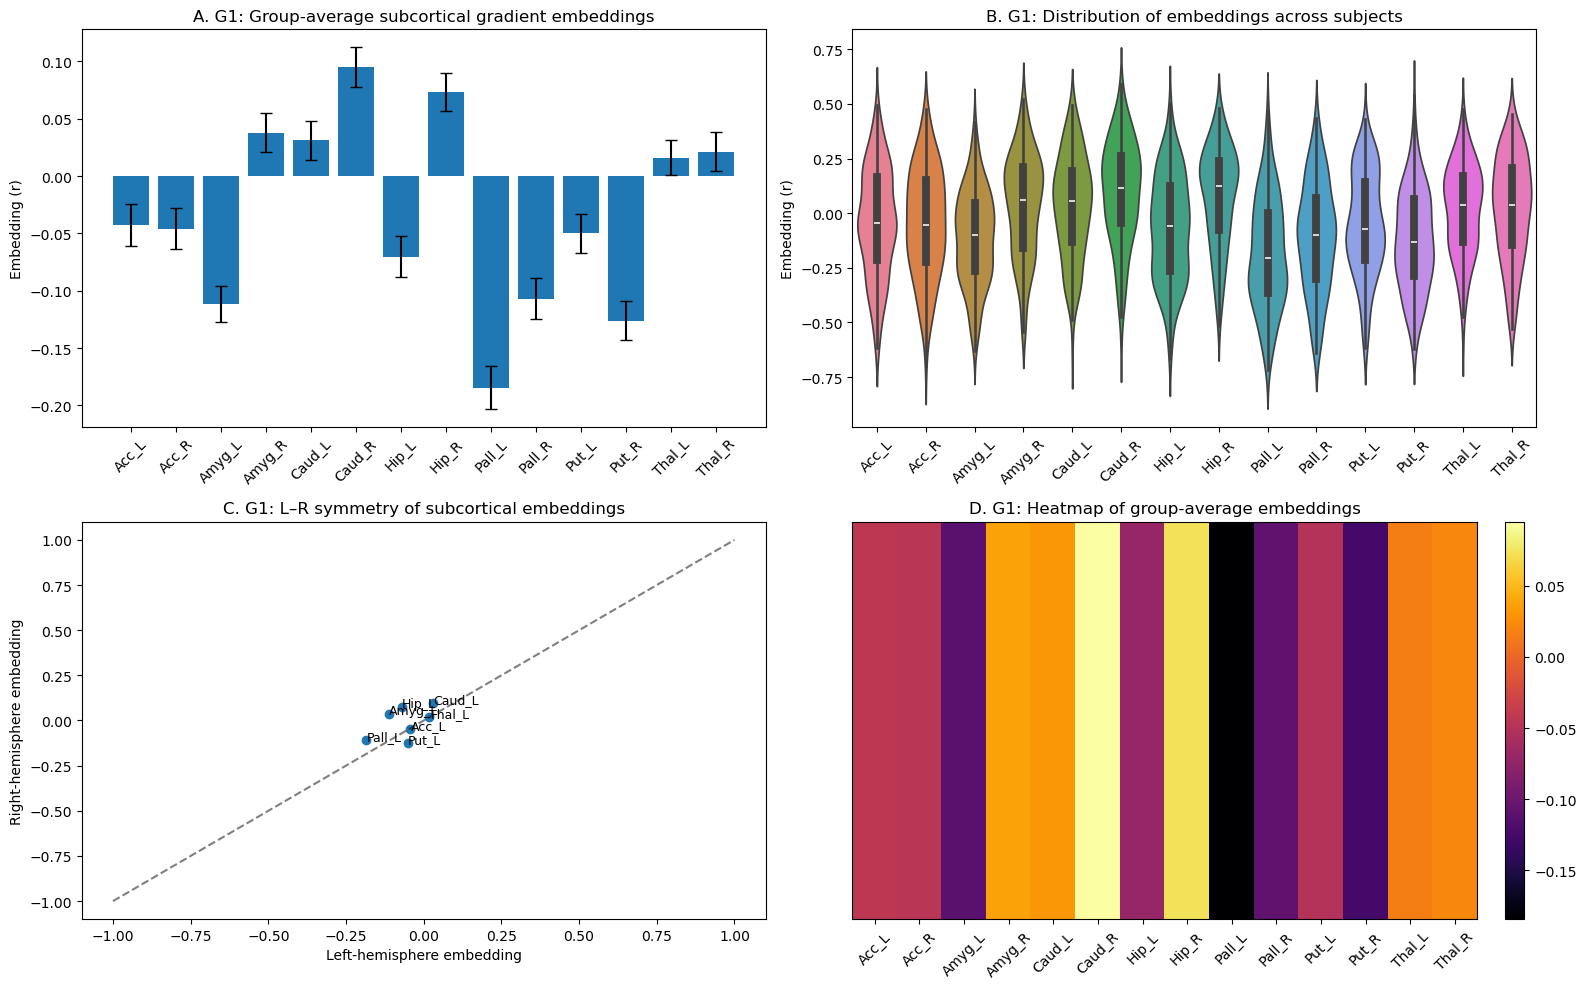

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
# embeddings_g1: n_subjects × 14 subcortical embedding values
# subcort_regions_g1: list of 14 subcortical names

group_mean_g1 = embeddings_g1.mean(axis=0)
group_sem_g1  = embeddings_g1.std(axis=0) / np.sqrt(embeddings_g1.shape[0])

# Short labels for plotting
labels_short_g1 = [
    'Acc_L','Acc_R','Amyg_L','Amyg_R',
    'Caud_L','Caud_R','Hip_L','Hip_R',
    'Pall_L','Pall_R','Put_L','Put_R',
    'Thal_L','Thal_R'
]

# Left/right vectors
left_vals_g1  = group_mean_g1[0::2]
right_vals_g1 = group_mean_g1[1::2]
pair_labels_g1 = labels_short_g1[0::2]

# --- Create multi-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axA, axB, axC, axD = axes.flat

# ======================
# Panel A: Bar + SEM
# ======================
axA.bar(range(14), group_mean_g1, yerr=group_sem_g1, capsize=4)
axA.set_xticks(range(14))
axA.set_xticklabels(labels_short_g1, rotation=45)
axA.set_ylabel("Embedding (r)")
axA.set_title("A. G1: Group-average subcortical gradient embeddings")

# ======================
# Panel B: Violin plot
# ======================
sns.violinplot(data=embeddings_g1, ax=axB, inner='box')
axB.set_xticks(range(14))
axB.set_xticklabels(labels_short_g1, rotation=45)
axB.set_ylabel("Embedding (r)")
axB.set_title("B. G1: Distribution of embeddings across subjects")

# ======================
# Panel C: L–R hemisphere asymmetry
# ======================
axC.scatter(left_vals_g1, right_vals_g1)
axC.plot([-1,1],[-1,1],'k--', alpha=0.5)
axC.set_xlabel("Left-hemisphere embedding")
axC.set_ylabel("Right-hemisphere embedding")
axC.set_title("C. G1: L–R symmetry of subcortical embeddings")

# Label points
for i, name in enumerate(pair_labels_g1):
    axC.text(left_vals_g1[i], right_vals_g1[i], name, fontsize=9, ha='left')

# ======================
# Panel D: Heatmap of group mean
# ======================
im = axD.imshow(group_mean_g1[np.newaxis,:], cmap='inferno', aspect='auto')
axD.set_xticks(range(14))
axD.set_xticklabels(labels_short_g1, rotation=45)
axD.set_yticks([])
axD.set_title("D. G1: Heatmap of group-average embeddings")
plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Statistical testing


In [44]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

# embeddings_g1: n_subjects × 14 subcortical embeddings
# subcort_regions_g1: list of 14 region names

# --- One-sample t-tests against zero ---
tvals_g1 = []
pvals_g1 = []
means_g1 = []

for i in range(14):
    vals = embeddings_g1[:, i]
    t, p = ttest_1samp(vals, 0)
    tvals_g1.append(t)
    pvals_g1.append(p)
    means_g1.append(vals.mean())

# --- FDR correction ---
reject_fdr_g1, pvals_fdr_g1 = fdrcorrection(pvals_g1, alpha=0.05)

# --- Interpretation based on gradient polarity ---
# Negative → primary sensory-aligned
# Positive → higher-order-aligned
interpretation_g1 = []
for m in means_g1:
    if m > 0:
        interpretation_g1.append("Somatomotor-aligned (+)")
    elif m < 0:
        interpretation_g1.append("Visual-aligned (–)")
    else:
        interpretation_g1.append("No alignment")

# --- Build summary table ---
summary_g1_df = pd.DataFrame({
    "Region": subcort_regions_g1,
    "MeanEmbedding": means_g1,
    "T_value": tvals_g1,
    "P_value": pvals_g1,
    "P_FDR": pvals_fdr_g1,
    "Significant(FDR<0.05)": reject_fdr_g1,
    "Interpretation": interpretation_g1
})

# Sort by mean embedding
summary_g1_df = summary_g1_df.sort_values(by="MeanEmbedding", ascending=False).reset_index(drop=True)

summary_g1_df


,Region,MeanEmbedding,T_value,P_value,P_FDR,Significant(FDR<0.05),Interpretation
0,sub_Caudate_R,0.095026,5.518062,1.137622e-07,3.185341e-07,True,Somatomotor-aligned (+)
1,sub_Hippocampus_R,0.073562,4.452386,1.461804e-05,3.410876e-05,True,Somatomotor-aligned (+)
2,sub_Amygdala_R,0.037697,2.198642,2.913711e-02,3.708359e-02,True,Somatomotor-aligned (+)
3,sub_Caudate_L,0.031361,1.845795,6.651143e-02,7.759667e-02,False,Somatomotor-aligned (+)
4,sub_Thalamus_R,0.021219,1.237545,2.174449e-01,2.341714e-01,False,Somatomotor-aligned (+)
5,sub_Thalamus_L,0.016169,1.069264,2.863366e-01,2.863366e-01,False,Somatomotor-aligned (+)
6,sub_Accumbens_L,-0.042719,-2.374588,1.858646e-02,2.602104e-02,True,Visual-aligned (–)
7,sub_Accumbens_R,-0.045784,-2.535364,1.205630e-02,1.875425e-02,True,Visual-aligned (–)
8,sub_Putamen_L,-0.050094,-2.906262,4.101998e-03,7.178496e-03,True,Visual-aligned (–)
9,sub_Hippocampus_L,-0.070173,-3.988057,9.566649e-05,1.913330e-04,True,Visual-aligned (–)


# G2

In [45]:
# --- Load aligned G2 gradient CSV (used in PLS) ---
# Rows = subjects, columns = metadata + nodes
g2_aligned = pd.read_csv("./g2_aligned_cog_updated.csv", index_col=0)

# --- Extract cortical parcel columns only ---
parcel_cols_g2 = [f"node_{i+1}" for i in range(400)]
g2_nodes = g2_aligned[parcel_cols_g2]

# --- Compute group-average gradient (length 400) ---
gradient_vec_g2 = g2_nodes.mean(axis=0).to_numpy()
print("G2 gradient vector shape:", gradient_vec_g2.shape)  # should be (400,)

# --- Function to compute subcortical embeddings with positive FC threshold ---
def compute_subcortical_embedding_corr_g2(fc_group_full, gradient_vec_g2):
    results_g2 = []
    for subj_fc in fc_group_full:
        # Threshold FC to keep only positive values
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)
        Ci_j_g2 = subj_fc_thr[-14:, :400]  # subcortex-to-cortex
        subj_vals_g2 = [pearsonr(Ci_j_g2[i, :], gradient_vec_g2)[0] for i in range(14)]
        results_g2.append(subj_vals_g2)
    return np.array(results_g2)

# --- Compute embeddings for all subjects ---
all_subjects_g2 = demo['participant_id_num'].tolist()
fc_full_list_g2 = [fc[i] for i in all_subjects_g2 if i in fc]

embeddings_g2 = compute_subcortical_embedding_corr_g2(fc_full_list_g2, gradient_vec_g2)

# --- Build DataFrame matching demo structure ---
subcort_regions_g2 = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

subcort_df_g2 = pd.DataFrame(embeddings_g2, columns=subcort_regions_g2)

# Keep the demo info
demo_subcort_g2 = demo.loc[demo['participant_id_num'].isin(all_subjects_g2)].copy()
demo_subcort_g2 = demo_subcort_g2.reset_index(drop=True)

# Merge embeddings with demographic info
demo_subcort_g2 = pd.concat([demo_subcort_g2, subcort_df_g2], axis=1)

# --- Save to CSV ---
demo_subcort_g2.to_csv('./g2_subcortical_embedding_corr_demo.csv', index=False)
print("Saved G2 subcortical embedding CSV with demographics!")

G2 gradient vector shape: (400,)
Saved G2 subcortical embedding CSV with demographics!


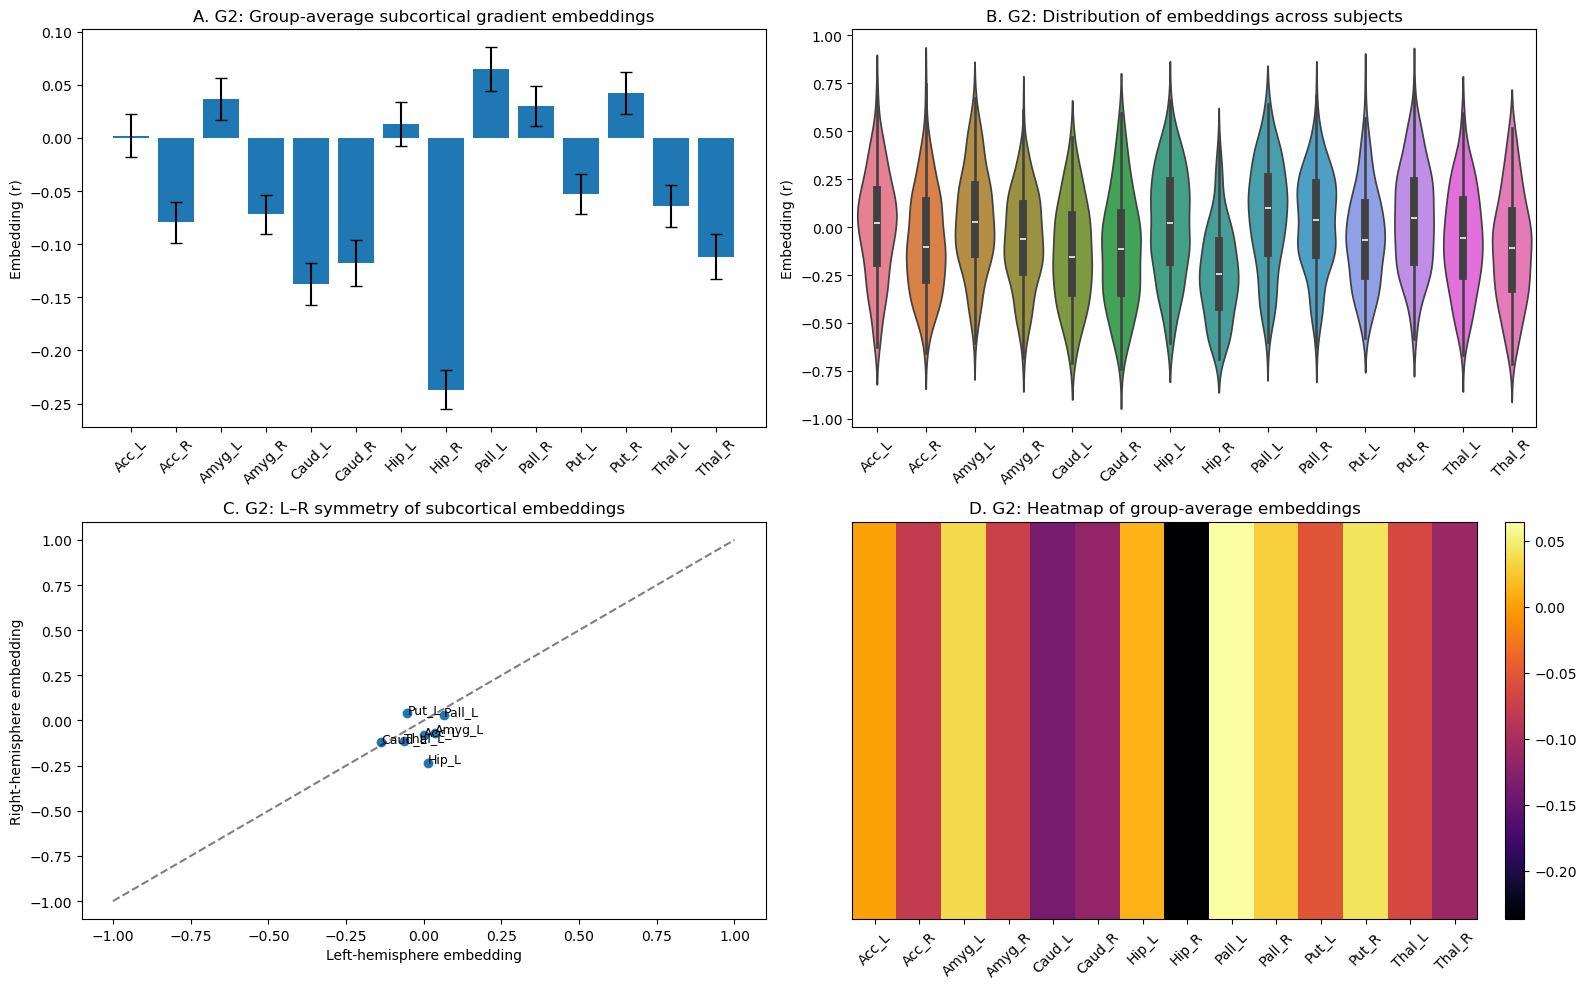

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
# embeddings_g2: n_subjects × 14 subcortical embedding values
# subcort_regions_g2: list of 14 subcortical names

group_mean_g2 = embeddings_g2.mean(axis=0)
group_sem_g2  = embeddings_g2.std(axis=0) / np.sqrt(embeddings_g2.shape[0])

# Short labels for plotting
labels_short_g2 = [
    'Acc_L','Acc_R','Amyg_L','Amyg_R',
    'Caud_L','Caud_R','Hip_L','Hip_R',
    'Pall_L','Pall_R','Put_L','Put_R',
    'Thal_L','Thal_R'
]

# Left/right vectors
left_vals_g2  = group_mean_g2[0::2]
right_vals_g2 = group_mean_g2[1::2]
pair_labels_g2 = labels_short_g2[0::2]

# --- Create multi-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axA, axB, axC, axD = axes.flat

# ======================
# Panel A: Bar + SEM
# ======================
axA.bar(range(14), group_mean_g2, yerr=group_sem_g2, capsize=4)
axA.set_xticks(range(14))
axA.set_xticklabels(labels_short_g2, rotation=45)
axA.set_ylabel("Embedding (r)")
axA.set_title("A. G2: Group-average subcortical gradient embeddings")

# ======================
# Panel B: Violin plot
# ======================
sns.violinplot(data=embeddings_g2, ax=axB, inner='box')
axB.set_xticks(range(14))
axB.set_xticklabels(labels_short_g2, rotation=45)
axB.set_ylabel("Embedding (r)")
axB.set_title("B. G2: Distribution of embeddings across subjects")

# ======================
# Panel C: L–R hemisphere asymmetry
# ======================
axC.scatter(left_vals_g2, right_vals_g2)
axC.plot([-1,1],[-1,1],'k--', alpha=0.5)
axC.set_xlabel("Left-hemisphere embedding")
axC.set_ylabel("Right-hemisphere embedding")
axC.set_title("C. G2: L–R symmetry of subcortical embeddings")

# Label points
for i, name in enumerate(pair_labels_g2):
    axC.text(left_vals_g2[i], right_vals_g2[i], name, fontsize=9, ha='left')

# ======================
# Panel D: Heatmap of group mean
# ======================
im = axD.imshow(group_mean_g2[np.newaxis,:], cmap='inferno', aspect='auto')
axD.set_xticks(range(14))
axD.set_xticklabels(labels_short_g2, rotation=45)
axD.set_yticks([])
axD.set_title("D. G2: Heatmap of group-average embeddings")
plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Statistical testing

In [47]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

# embeddings_g2: n_subjects × 14 subcortical embeddings
# subcort_regions_g2: list of 14 region names

# --- One-sample t-tests against zero ---
tvals_g2 = []
pvals_g2 = []
means_g2 = []

for i in range(14):
    vals = embeddings_g2[:, i]
    t, p = ttest_1samp(vals, 0)
    tvals_g2.append(t)
    pvals_g2.append(p)
    means_g2.append(vals.mean())

# --- FDR correction ---
reject_fdr_g2, pvals_fdr_g2 = fdrcorrection(pvals_g2, alpha=0.05)

# --- Interpretation based on gradient polarity ---
# Negative → primary sensory-aligned
# Positive → higher-order-aligned
interpretation_g2 = []
for m in means_g2:
    if m > 0:
        interpretation_g2.append("Higher-order-aligned (+)")
    elif m < 0:
        interpretation_g2.append("Primary sensory-aligned (–)")
    else:
        interpretation_g2.append("No alignment")

# --- Build summary table ---
summary_g2_df = pd.DataFrame({
    "Region": subcort_regions_g2,
    "MeanEmbedding": means_g2,
    "T_value": tvals_g2,
    "P_value": pvals_g2,
    "P_FDR": pvals_fdr_g2,
    "Significant(FDR<0.05)": reject_fdr_g2,
    "Interpretation": interpretation_g2
})

# Sort by mean embedding
summary_g2_df = summary_g2_df.sort_values(by="MeanEmbedding", ascending=False).reset_index(drop=True)

summary_g2_df


,Region,MeanEmbedding,T_value,P_value,P_FDR,Significant(FDR<0.05),Interpretation
0,sub_Pallidum_L,0.064417,3.111922,2.152007e-03,3.766011e-03,True,Higher-order-aligned (+)
1,sub_Putamen_R,0.042121,2.110995,3.610889e-02,5.055245e-02,False,Higher-order-aligned (+)
2,sub_Amygdala_L,0.036462,1.853591,6.538148e-02,8.321279e-02,False,Higher-order-aligned (+)
3,sub_Pallidum_R,0.030002,1.596046,1.121761e-01,1.308721e-01,False,Higher-order-aligned (+)
4,sub_Hippocampus_L,0.013100,0.627103,5.313607e-01,5.722346e-01,False,Higher-order-aligned (+)
5,sub_Accumbens_L,0.002134,0.104986,9.165004e-01,9.165004e-01,False,Higher-order-aligned (+)
6,sub_Putamen_L,-0.052416,-2.784523,5.915073e-03,9.201225e-03,True,Primary sensory-aligned (–)
7,sub_Thalamus_L,-0.064487,-3.266764,1.295379e-03,2.590757e-03,True,Primary sensory-aligned (–)
8,sub_Amygdala_R,-0.071768,-3.921464,1.236769e-04,2.885794e-04,True,Primary sensory-aligned (–)
9,sub_Accumbens_R,-0.079593,-4.062702,7.146418e-05,2.000997e-04,True,Primary sensory-aligned (–)


# G3

In [48]:
# --- Load aligned G3 gradient CSV (used in PLS) ---
g3_aligned = pd.read_csv("./g3_aligned_cog_updated.csv", index_col=0)

# --- Extract cortical parcel columns only ---
parcel_cols_g3 = [f"node_{i+1}" for i in range(400)]
g3_nodes = g3_aligned[parcel_cols_g3]

# --- Compute group-average gradient (length 400) ---
gradient_vec_g3 = g3_nodes.mean(axis=0).to_numpy()
print("G3 gradient vector shape:", gradient_vec_g3.shape)  # should be (400,)

# --- Function to compute subcortical embeddings with positive FC threshold ---
def compute_subcortical_embedding_corr_g3(fc_group_full, gradient_vec_g3):
    results_g3 = []
    for subj_fc in fc_group_full:
        # Threshold FC to keep only positive values
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)
        Ci_j_g3 = subj_fc_thr[-14:, :400]  # subcortex-to-cortex
        subj_vals_g3 = [pearsonr(Ci_j_g3[i, :], gradient_vec_g3)[0] for i in range(14)]
        results_g3.append(subj_vals_g3)
    return np.array(results_g3)

# --- Compute embeddings for all subjects ---
all_subjects_g3 = demo['participant_id_num'].tolist()
fc_full_list_g3 = [fc[i] for i in all_subjects_g3 if i in fc]

embeddings_g3 = compute_subcortical_embedding_corr_g3(fc_full_list_g3, gradient_vec_g3)

# --- Build DataFrame matching demo structure ---
subcort_regions_g3 = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

subcort_df_g3 = pd.DataFrame(embeddings_g3, columns=subcort_regions_g3)

# Keep the demo info
demo_subcort_g3 = demo.loc[demo['participant_id_num'].isin(all_subjects_g3)].copy()
demo_subcort_g3 = demo_subcort_g3.reset_index(drop=True)

# Merge embeddings with demographic info
demo_subcort_g3 = pd.concat([demo_subcort_g3, subcort_df_g3], axis=1)

# --- Save to CSV ---
demo_subcort_g3.to_csv('./g3_subcortical_embedding_corr_demo.csv', index=False)
print("Saved G3 subcortical embedding CSV with demographics!")


G3 gradient vector shape: (400,)
Saved G3 subcortical embedding CSV with demographics!


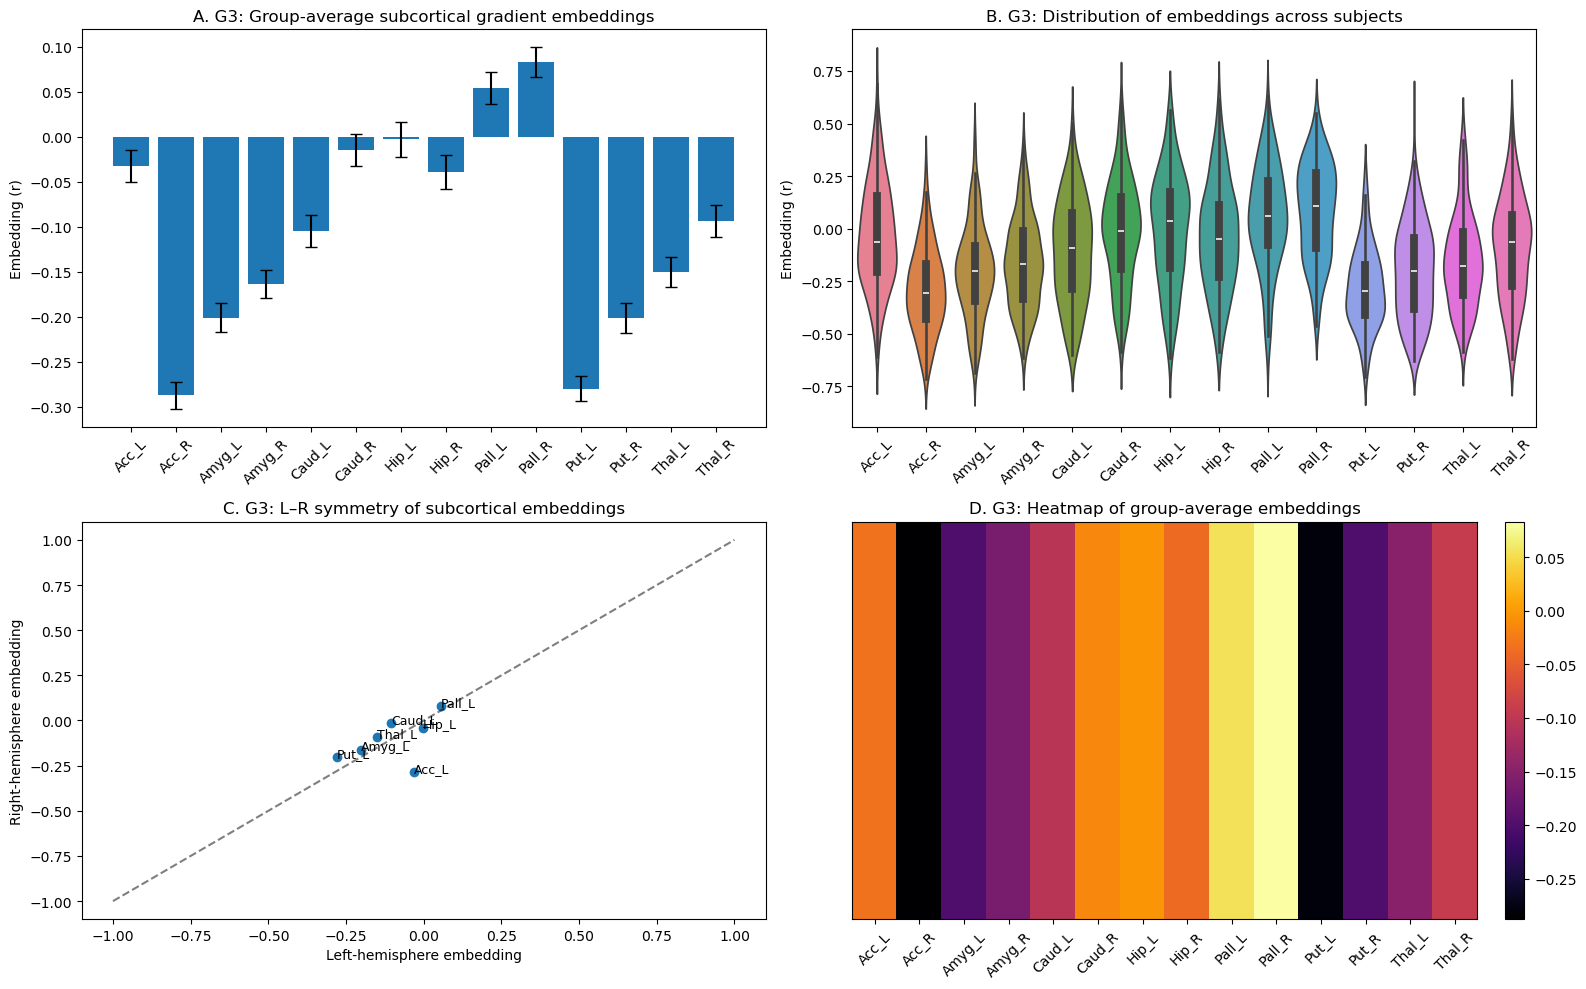

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
# embeddings_g3: n_subjects × 14 subcortical embedding values

group_mean_g3 = embeddings_g3.mean(axis=0)
group_sem_g3  = embeddings_g3.std(axis=0) / np.sqrt(embeddings_g3.shape[0])

# Short labels for plotting
labels_short_g3 = [
    'Acc_L','Acc_R','Amyg_L','Amyg_R',
    'Caud_L','Caud_R','Hip_L','Hip_R',
    'Pall_L','Pall_R','Put_L','Put_R',
    'Thal_L','Thal_R'
]

# Left/right vectors
left_vals_g3  = group_mean_g3[0::2]
right_vals_g3 = group_mean_g3[1::2]
pair_labels_g3 = labels_short_g3[0::2]

# --- Create multi-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axA, axB, axC, axD = axes.flat

# ======================
# Panel A: Bar + SEM
# ======================
axA.bar(range(14), group_mean_g3, yerr=group_sem_g3, capsize=4)
axA.set_xticks(range(14))
axA.set_xticklabels(labels_short_g3, rotation=45)
axA.set_ylabel("Embedding (r)")
axA.set_title("A. G3: Group-average subcortical gradient embeddings")

# ======================
# Panel B: Violin plot
# ======================
sns.violinplot(data=embeddings_g3, ax=axB, inner='box')
axB.set_xticks(range(14))
axB.set_xticklabels(labels_short_g3, rotation=45)
axB.set_ylabel("Embedding (r)")
axB.set_title("B. G3: Distribution of embeddings across subjects")

# ======================
# Panel C: L–R hemisphere asymmetry
# ======================
axC.scatter(left_vals_g3, right_vals_g3)
axC.plot([-1,1],[-1,1],'k--', alpha=0.5)
axC.set_xlabel("Left-hemisphere embedding")
axC.set_ylabel("Right-hemisphere embedding")
axC.set_title("C. G3: L–R symmetry of subcortical embeddings")

# Label points
for i, name in enumerate(pair_labels_g3):
    axC.text(left_vals_g3[i], right_vals_g3[i], name, fontsize=9, ha='left')

# ======================
# Panel D: Heatmap of group mean
# ======================
im = axD.imshow(group_mean_g3[np.newaxis,:], cmap='inferno', aspect='auto')
axD.set_xticks(range(14))
axD.set_xticklabels(labels_short_g3, rotation=45)
axD.set_yticks([])
axD.set_title("D. G3: Heatmap of group-average embeddings")
plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Statistical testing

In [50]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

# embeddings_g3: n_subjects × 14 subcortical embeddings
# subcort_regions_g3: list of 14 region names

# --- One-sample t-tests against zero ---
tvals_g3 = []
pvals_g3 = []
means_g3 = []

for i in range(14):
    vals = embeddings_g3[:, i]
    t, p = ttest_1samp(vals, 0)
    tvals_g3.append(t)
    pvals_g3.append(p)
    means_g3.append(vals.mean())

# --- FDR correction ---
reject_fdr_g3, pvals_fdr_g3 = fdrcorrection(pvals_g3, alpha=0.05)

# --- Interpretation based on gradient polarity ---
# Negative → Multi-demand-aligned
# Positive → Exteroceptive-aligned
interpretation_g3 = []
for m in means_g3:
    if m > 0:
        interpretation_g3.append("Exteroceptive-aligned (+)")
    elif m < 0:
        interpretation_g3.append("Multi-demand-aligned (–)")
    else:
        interpretation_g3.append("No alignment")

# --- Build summary table ---
summary_g3_df = pd.DataFrame({
    "Region": subcort_regions_g3,
    "MeanEmbedding": means_g3,
    "T_value": tvals_g3,
    "P_value": pvals_g3,
    "P_FDR": pvals_fdr_g3,
    "Significant(FDR<0.05)": reject_fdr_g3,
    "Interpretation": interpretation_g3
})

# Sort by mean embedding
summary_g3_df = summary_g3_df.sort_values(by="MeanEmbedding", ascending=False).reset_index(drop=True)

summary_g3_df


,Region,MeanEmbedding,T_value,P_value,P_FDR,Significant(FDR<0.05),Interpretation
0,sub_Pallidum_R,0.082850,4.958974,1.590910e-06,2.474749e-06,True,Exteroceptive-aligned (+)
1,sub_Pallidum_L,0.054385,3.023593,2.850645e-03,3.990903e-03,True,Exteroceptive-aligned (+)
2,sub_Hippocampus_L,-0.002593,-0.133775,8.937248e-01,8.937248e-01,False,Multi-demand-aligned (–)
3,sub_Caudate_R,-0.014581,-0.803702,4.225953e-01,4.551026e-01,False,Multi-demand-aligned (–)
4,sub_Accumbens_L,-0.032667,-1.812360,7.154322e-02,8.346709e-02,False,Multi-demand-aligned (–)
5,sub_Hippocampus_R,-0.039376,-2.097049,3.734111e-02,4.752505e-02,True,Multi-demand-aligned (–)
6,sub_Thalamus_R,-0.093525,-5.254874,4.033405e-07,7.058458e-07,True,Multi-demand-aligned (–)
7,sub_Caudate_L,-0.105162,-5.875187,1.914567e-08,3.829135e-08,True,Multi-demand-aligned (–)
8,sub_Thalamus_L,-0.150140,-9.061149,1.782035e-16,4.158082e-16,True,Multi-demand-aligned (–)
9,sub_Amygdala_R,-0.163910,-10.545204,1.114991e-20,3.121975e-20,True,Multi-demand-aligned (–)


# Differences between simple correlation (previous) and weighted manifold (following)
| Feature            | Correlation-based Subcortical Embedding                                                 | Weighted Subcortical Manifold                                                                                                   |
| ------------------ | --------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **Measure**        | Pearson correlation between each subcortical ROI’s FC profile and the cortical gradient | Weighted mean of subcortical FC × cortical gradient                                                                             |
| **Input**          | Subcortex-to-cortex FC matrix, cortical gradient                                        | Subcortex-to-cortex FC matrix, cortical gradient                                                                                |
| **Thresholding**   | Optional positive-only (here, positive-only applied)                                    | Always positive-only                                                                                                            |
| **Values / Scale** | r-values between –1 and 1                                                               | Positive real numbers, proportional to FC strength and gradient                                                                 |
| **Interpretation** | Pattern similarity to cortical gradient                                                 | Magnitude of “gradient-aligned connectivity strength”                                                                           |
| **Output shape**   | `(n_subjects × 14)`                                                                     | `(n_subjects × 14)`                                                                                                             |
| **Pros**           | Normalized, comparable across gradients, easy to interpret polarity                     | Captures absolute weighted contribution of cortical gradient; may reflect stronger signal in more connected subcortical regions |
| **Cons**           | Ignores magnitude; can be noisy if FC is weak                                           | Scale depends on FC; not bounded, harder to compare across gradients                                                            |


## Compute subcortical weighted manifold (nodal degree)
This section computes the weighted manifold for each subcortical region using the formula:
$$M_{i} = \frac{1}{N}\sum_{j=1}^{N} C_{i,j} \cdot G_{j}$$
where $C_{i,j}$ is the connectivity between subcortical region $i$ and cortical parcel $j$, $G_{j}$ is the gradient value for cortical parcel $j$, and $N$ is the number of cortical parcels.

In [51]:
import numpy as np

# --- Function: compute subcortical weighted manifold ---
def compute_subcortical_weighted_manifold(fc_group_full, gradient_vec):
    """
    Compute subcortical weighted manifold index.
    Thresholds FC to keep only positive values.
    """
    results = []
    for subj_fc in fc_group_full:
        # Threshold at 0: keep only positive correlations
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)
        # Subcortex-to-cortex connectivity
        Ci_j = subj_fc_thr[-14:, :400]
        # Weighted mean embedding
        Mi = (Ci_j * gradient_vec[np.newaxis, :]).mean(axis=1)
        results.append(Mi)
    return np.array(results)

# --- Dictionary of gradients ---
gradients = {
    'G1': gradient_vec_g1,
    'G2': gradient_vec_g2,
    'G3': gradient_vec_g3
}

# --- Compute weighted manifolds for all subjects and all gradients ---
Mi_all = {}  # will store results per gradient

# Example: fc_all = concatenated list of all subjects' FC matrices (CTR+SCZ+BD+mix)
# Concatenate all subjects along the first axis (subject dimension)
fc_all = np.concatenate([fc_CTR_full, fc_SCZ_full, fc_BD_full, fc_mix_full], axis=0)
print("fc_all shape:", fc_all.shape)  # should be (n_total_subjects, 419, 419)

for g_name, g_vec in gradients.items():
    Mi_all[g_name] = compute_subcortical_weighted_manifold(fc_all, g_vec)
    print(f"{g_name} weighted manifold shape:", Mi_all[g_name].shape)


fc_all shape: (264, 419, 419)
G1 weighted manifold shape: (264, 14)
G2 weighted manifold shape: (264, 14)
G3 weighted manifold shape: (264, 14)


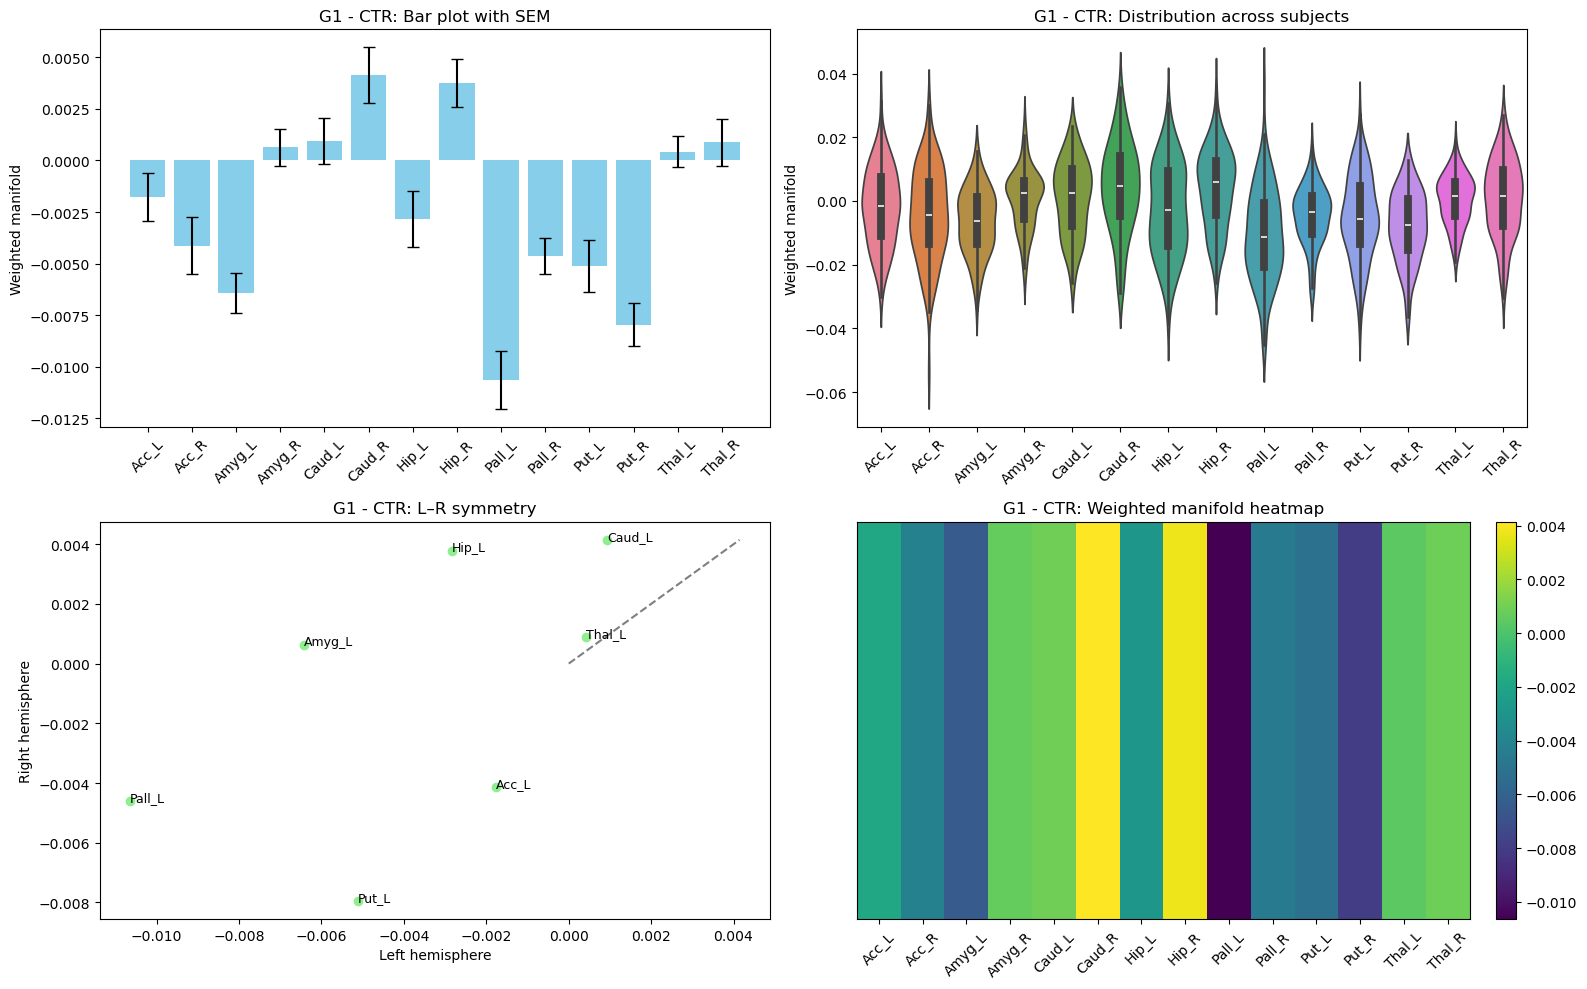

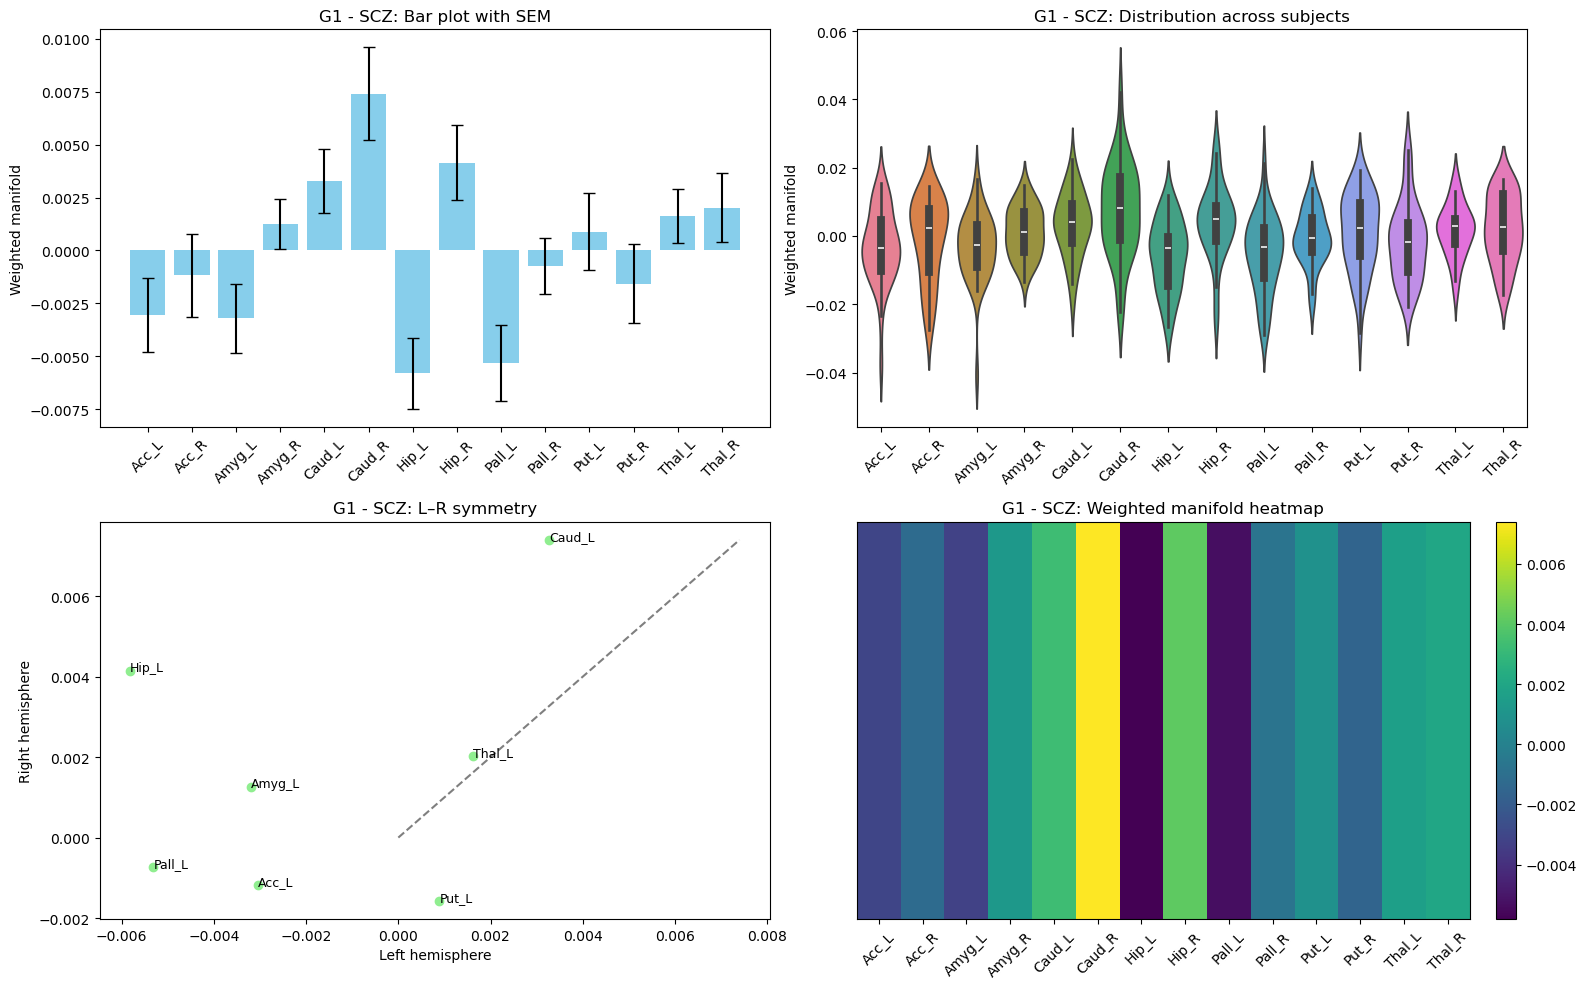

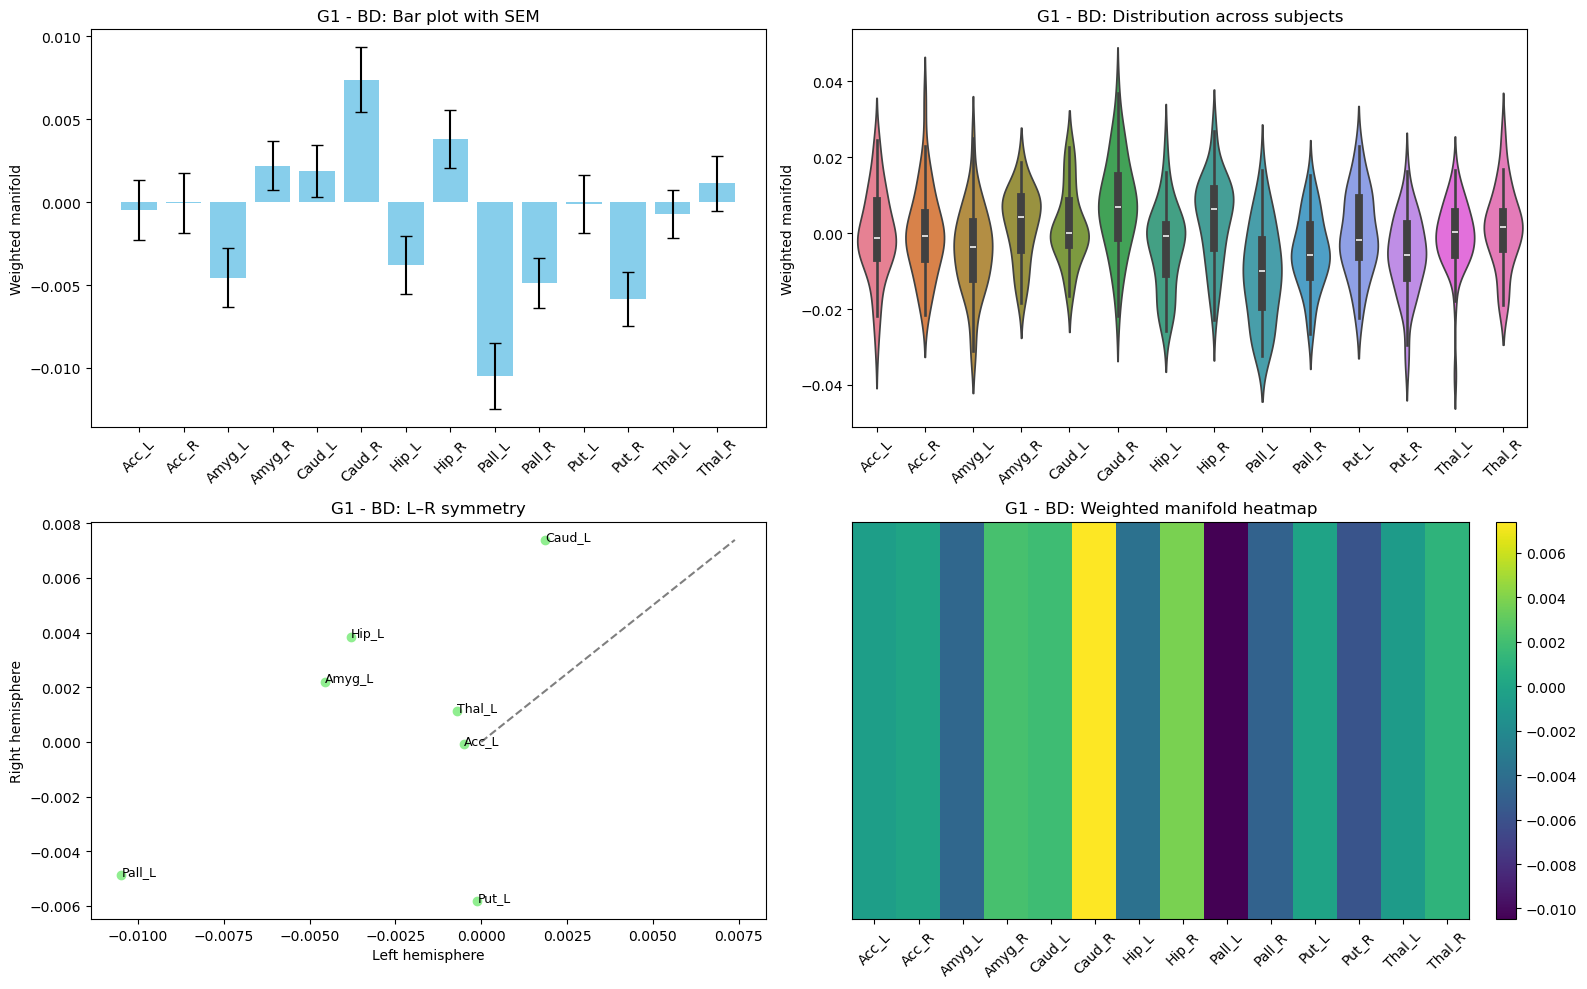

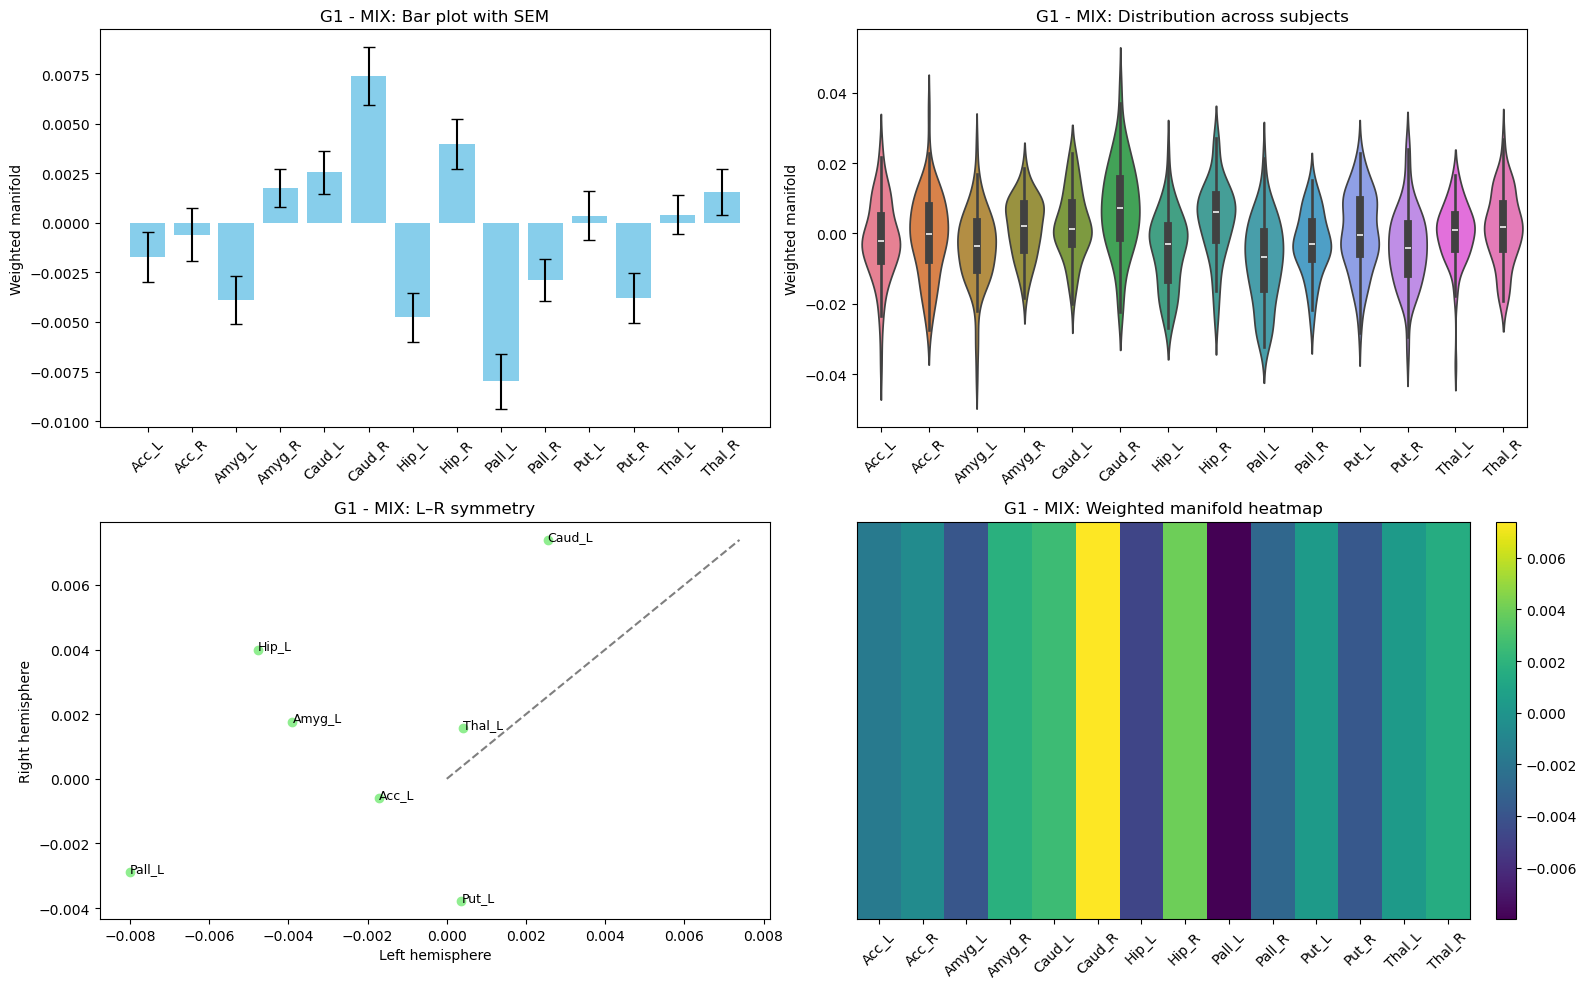

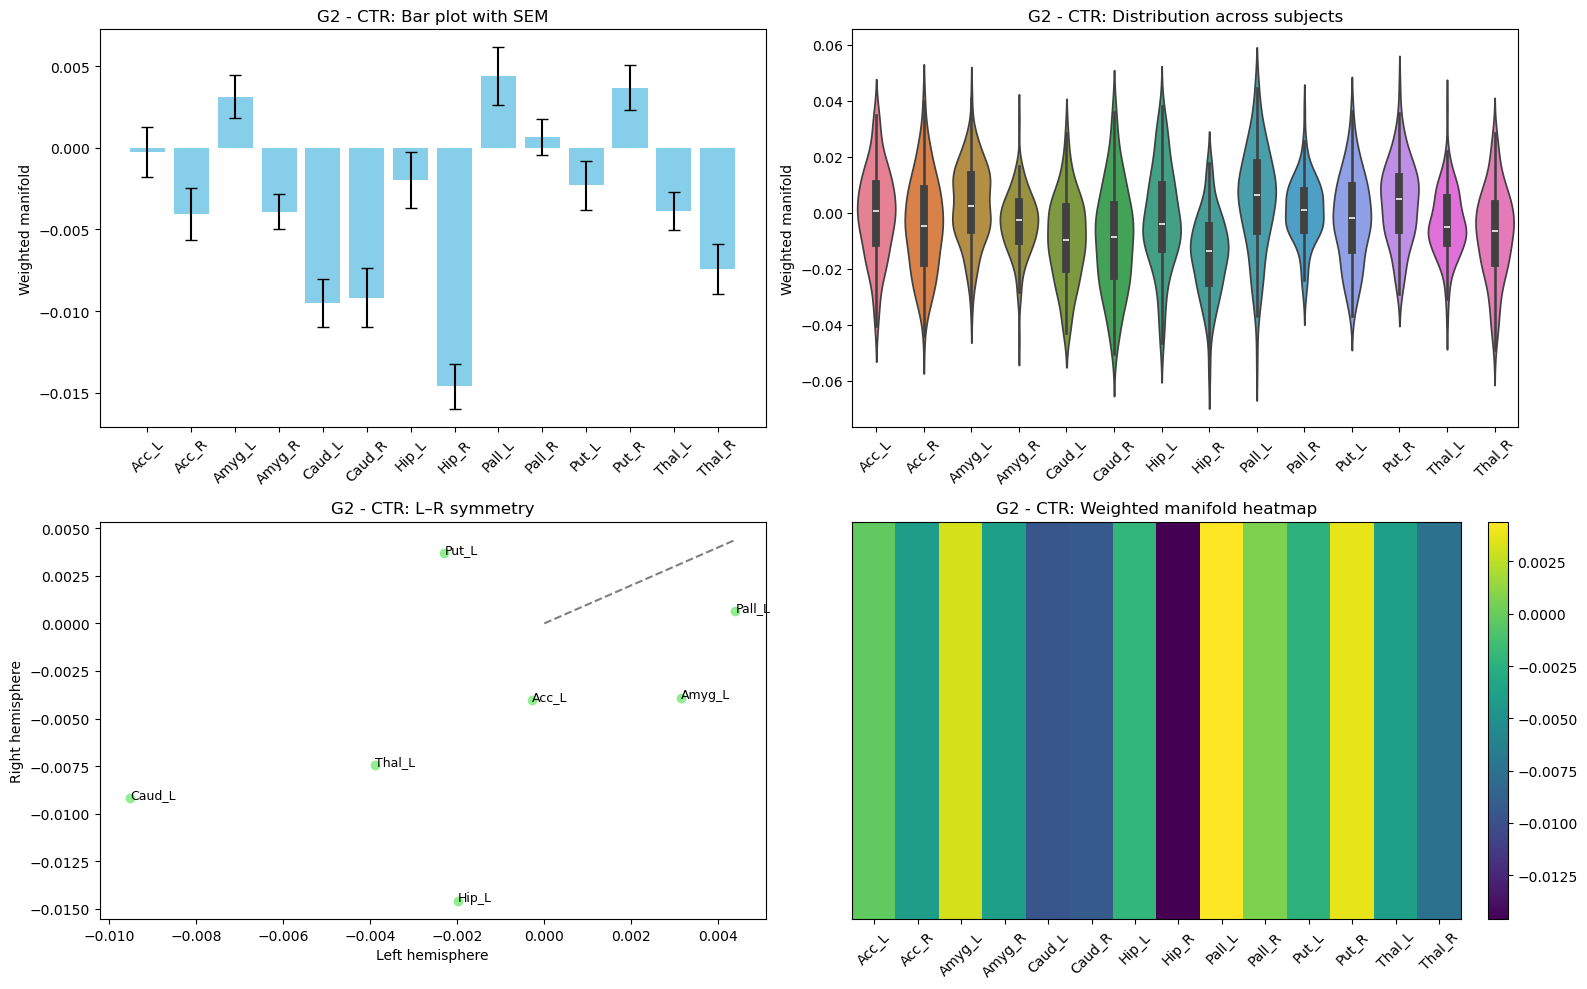

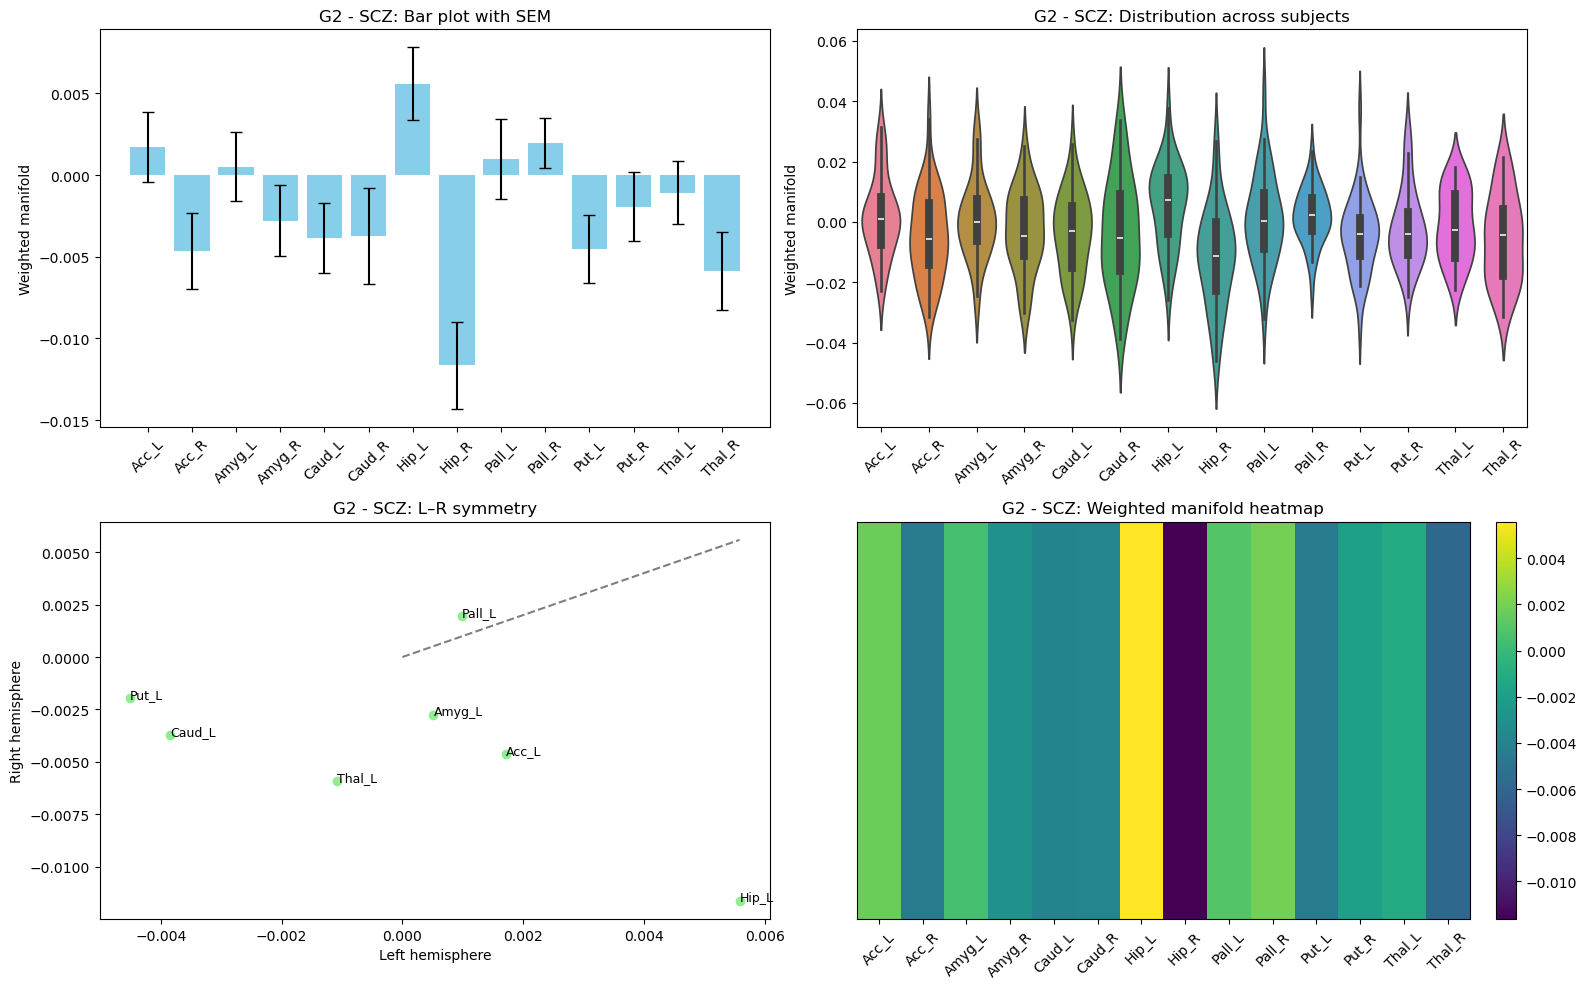

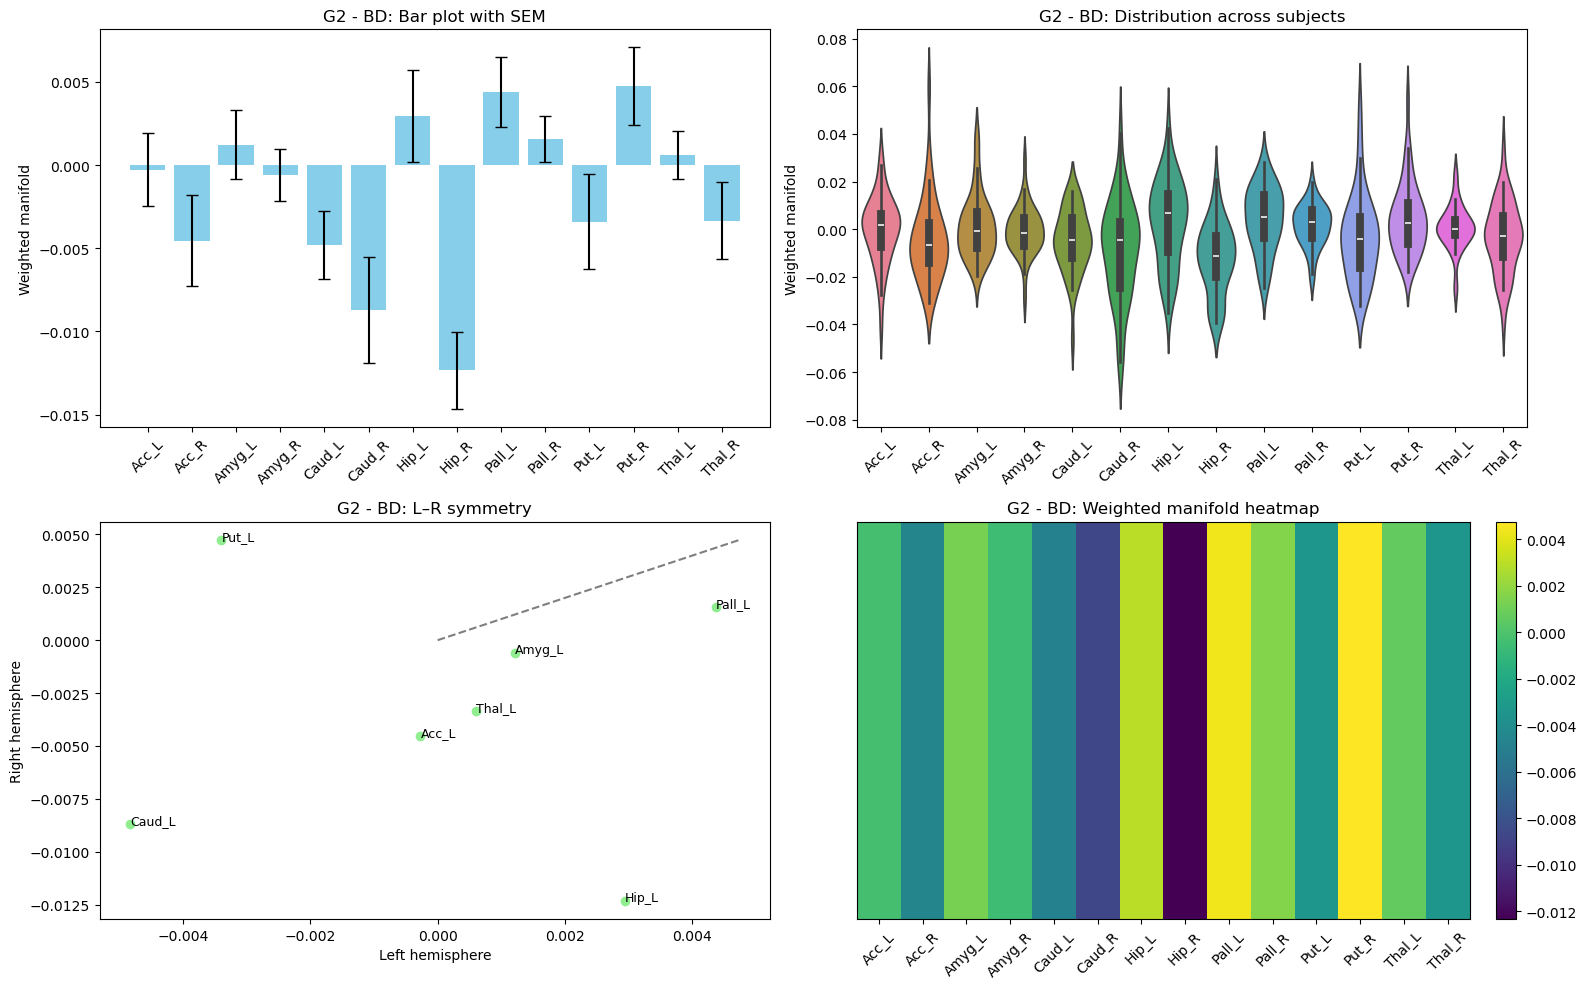

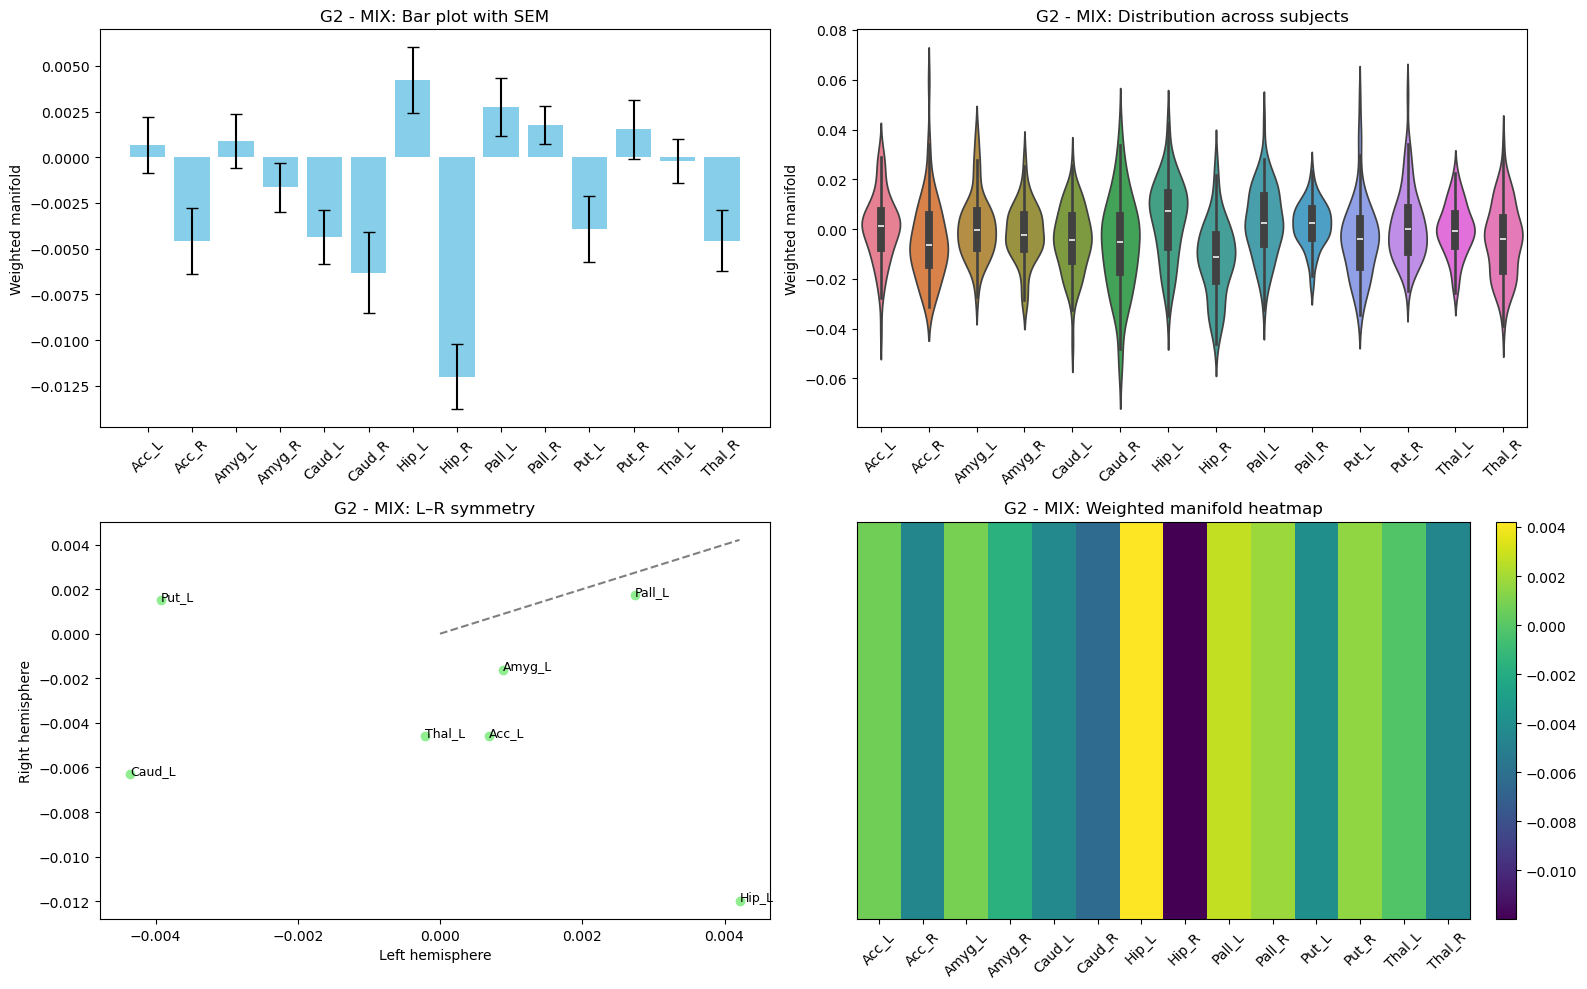

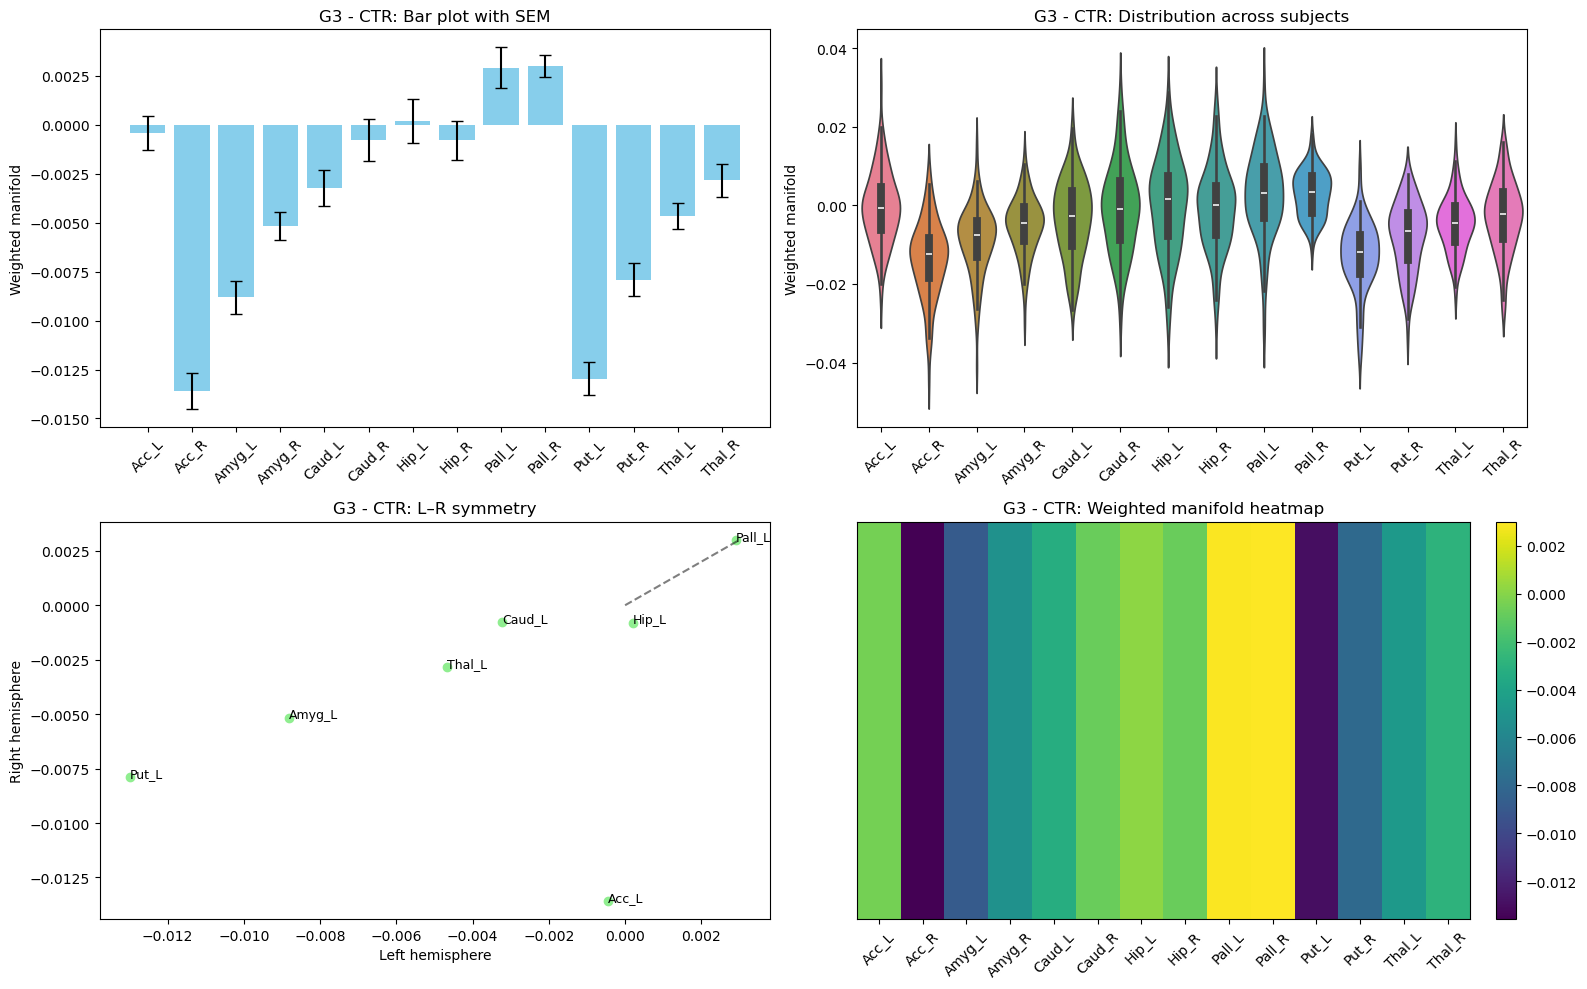

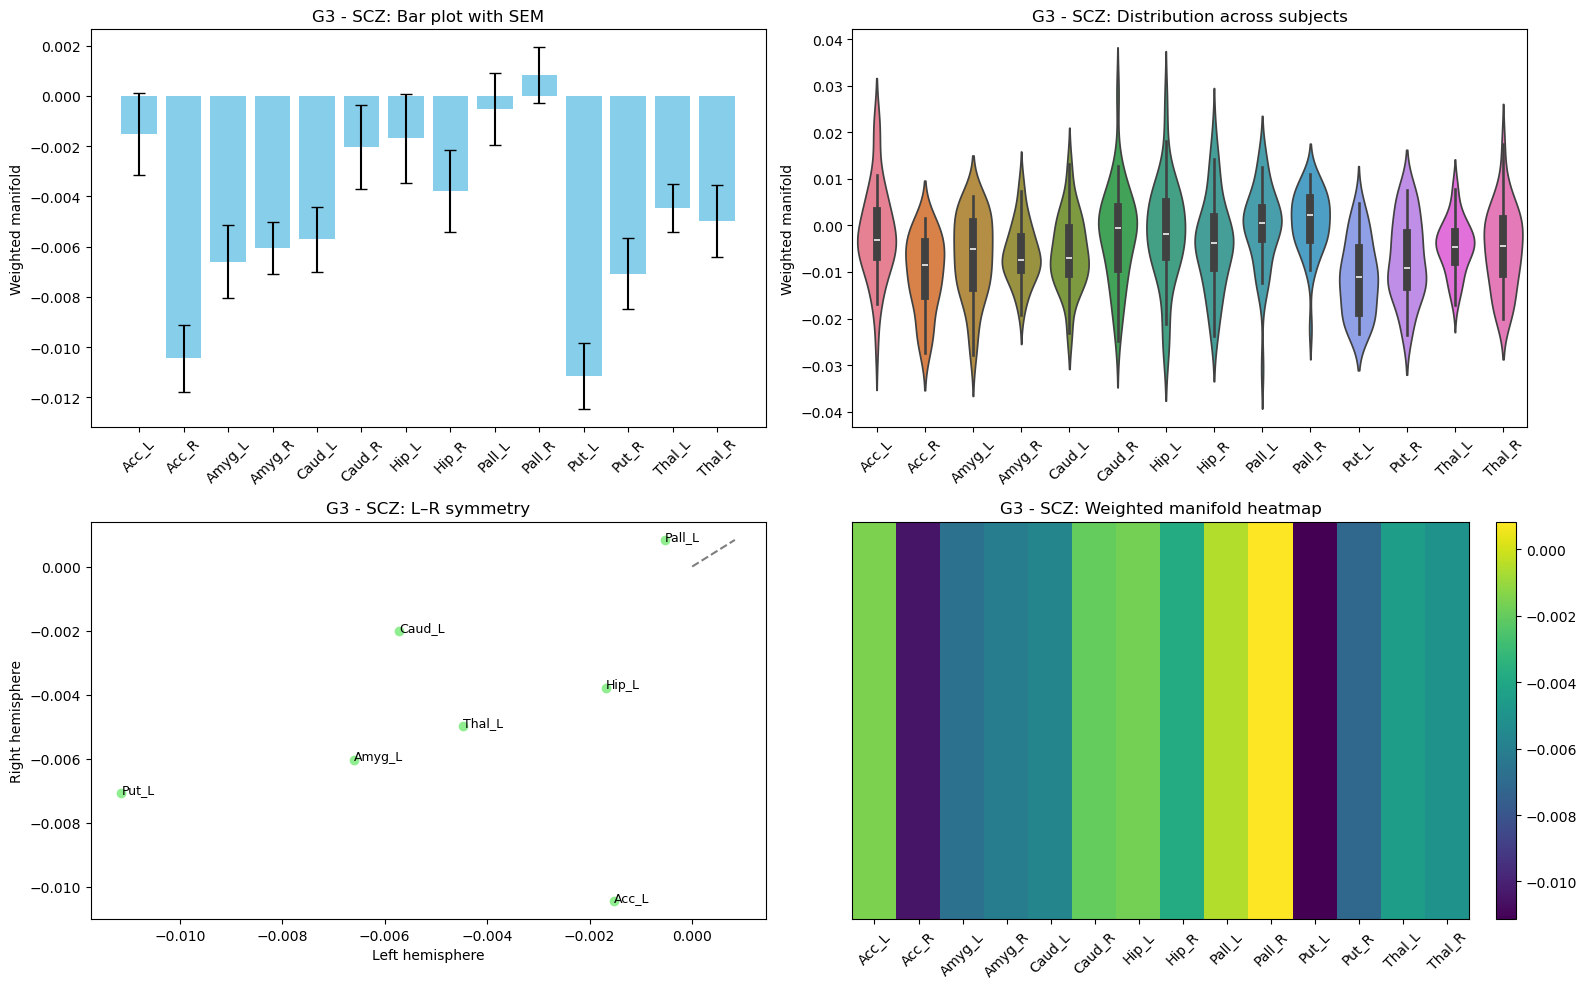

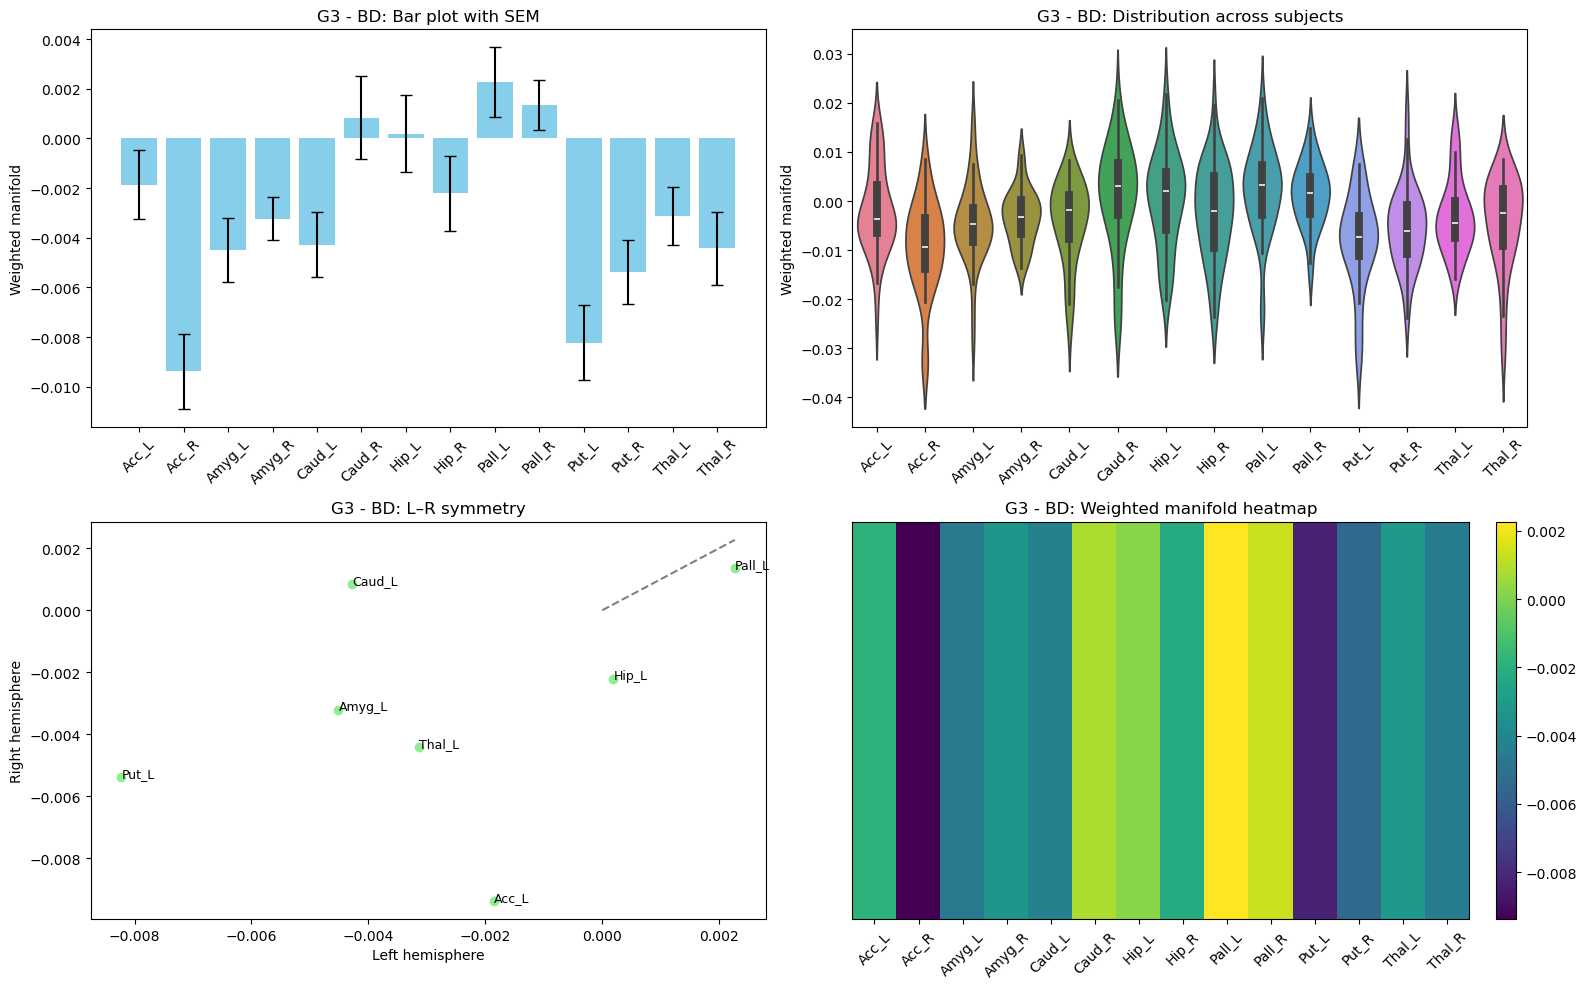

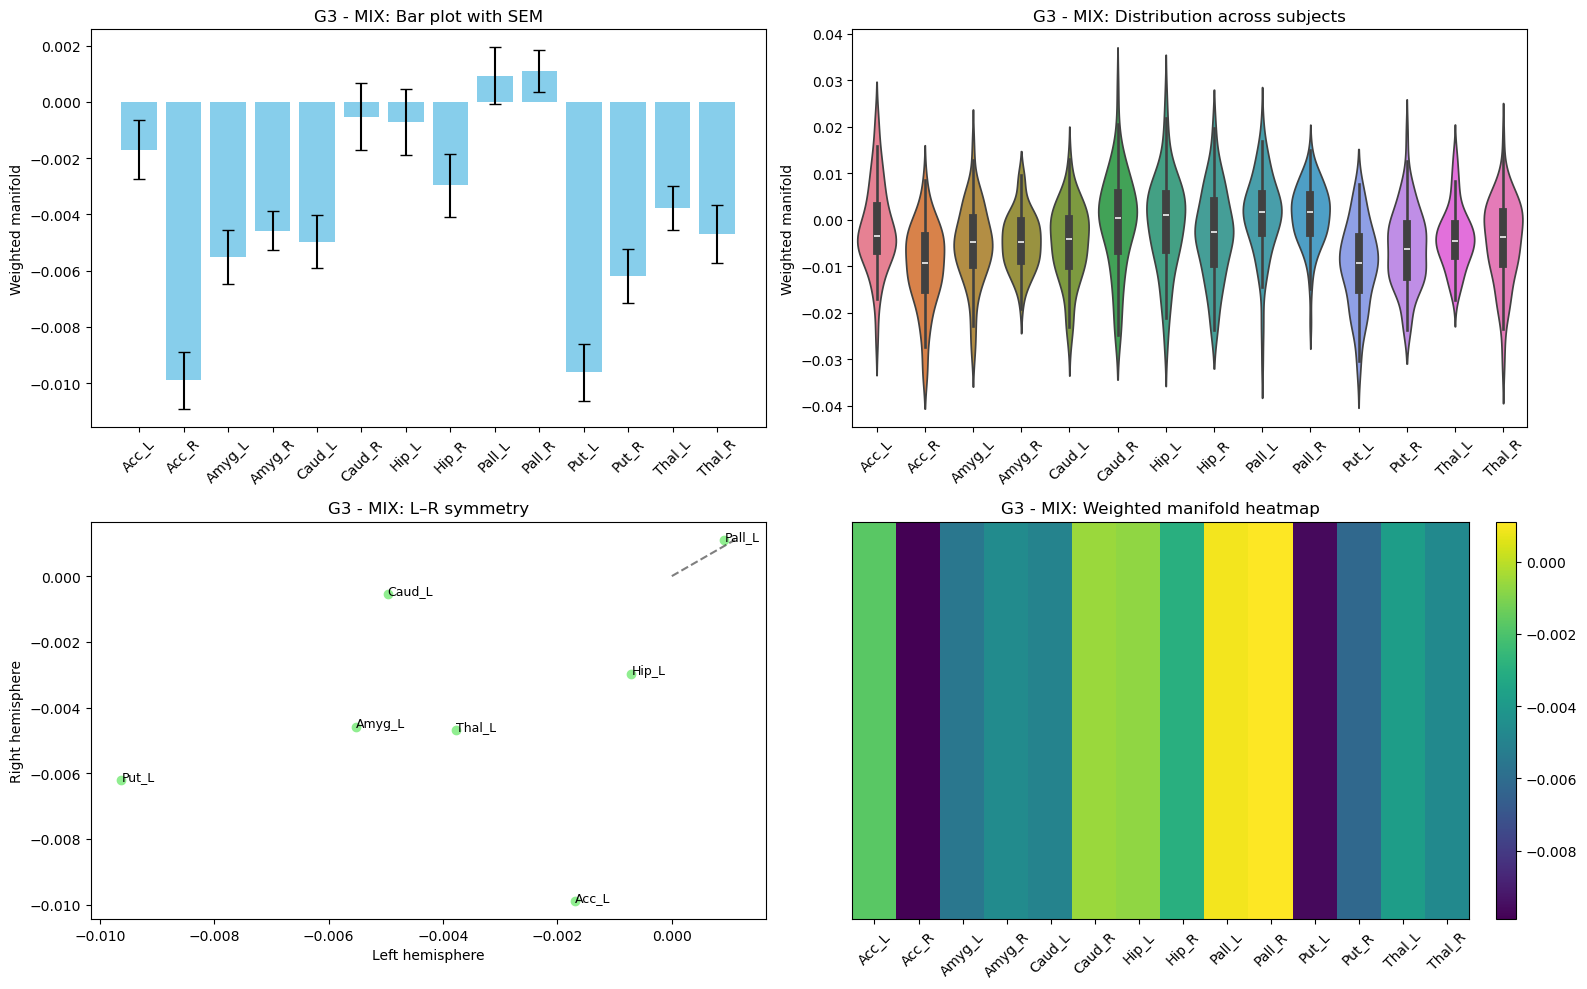

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Subcortical labels ---
labels_short = [
    'Acc_L','Acc_R','Amyg_L','Amyg_R',
    'Caud_L','Caud_R','Hip_L','Hip_R',
    'Pall_L','Pall_R','Put_L','Put_R',
    'Thal_L','Thal_R'
]

# --- Function to plot weighted manifold for one group ---
def plot_group_manifold(manifold_data, group_name, gradient_name):
    group_mean = manifold_data.mean(axis=0)
    group_sem  = manifold_data.std(axis=0) / np.sqrt(manifold_data.shape[0])
    
    # Left/right values for L–R symmetry
    left_vals  = group_mean[0::2]
    right_vals = group_mean[1::2]
    pair_labels = labels_short[0::2]

    fig, axes = plt.subplots(2, 2, figsize=(16,10))
    axA, axB, axC, axD = axes.flat

    # Panel A: Bar + SEM
    axA.bar(range(14), group_mean, yerr=group_sem, capsize=4, color='skyblue')
    axA.set_xticks(range(14))
    axA.set_xticklabels(labels_short, rotation=45)
    axA.set_ylabel("Weighted manifold")
    axA.set_title(f"{gradient_name} - {group_name}: Bar plot with SEM")

    # Panel B: Violin plot (all subjects)
    sns.violinplot(data=manifold_data, ax=axB, inner='box')
    axB.set_xticks(range(14))
    axB.set_xticklabels(labels_short, rotation=45)
    axB.set_ylabel("Weighted manifold")
    axB.set_title(f"{gradient_name} - {group_name}: Distribution across subjects")

    # Panel C: L–R symmetry
    axC.scatter(left_vals, right_vals, color='lightgreen')
    axC.plot([0, max(left_vals.max(), right_vals.max())], 
             [0, max(left_vals.max(), right_vals.max())], 'k--', alpha=0.5)
    axC.set_xlabel("Left hemisphere")
    axC.set_ylabel("Right hemisphere")
    axC.set_title(f"{gradient_name} - {group_name}: L–R symmetry")
    for i, name in enumerate(pair_labels):
        axC.text(left_vals[i], right_vals[i], name, fontsize=9, ha='left')

    # Panel D: Heatmap of group mean
    im = axD.imshow(group_mean[np.newaxis,:], cmap='viridis', aspect='auto')
    axD.set_xticks(range(14))
    axD.set_xticklabels(labels_short, rotation=45)
    axD.set_yticks([])
    axD.set_title(f"{gradient_name} - {group_name}: Weighted manifold heatmap")
    plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# --- Loop over gradients and plot each group ---
for gradient_name, manifold_data in Mi_all.items():
    n_subjects = manifold_data.shape[0]
    # Define groups assuming ordering: CTR, SCZ, BD, MIX
    n_CTR = len(fc_CTR_full)
    n_SCZ = len(fc_SCZ_full)
    n_BD  = len(fc_BD_full)
    n_MIX = len(fc_mix_full)
    
    groups = {
        "CTR": manifold_data[0:n_CTR, :],
        "SCZ": manifold_data[n_CTR:n_CTR+n_SCZ, :],
        "BD":  manifold_data[n_CTR+n_SCZ:n_CTR+n_SCZ+n_BD, :],
        "MIX": manifold_data[n_CTR+n_SCZ+n_BD:, :]
    }
    
    for group_name, data in groups.items():
        plot_group_manifold(data, group_name, gradient_name)


# Group comparison

In [53]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# --- Subcortical ROIs ---
subcort_regions = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

# --- Function to perform t-tests with optional FDR ---
def compare_groups(subcort_data, group_labels, group1, group2, fisher_corr=False, fdr=True):
    """
    Performs independent t-tests for each subcortical ROI between two groups.
    Optionally applies Fisher z-transform for correlation embeddings.
    """
    subcort_data = np.array(subcort_data)
    group1_idx = [i for i, g in enumerate(group_labels) if g == group1]
    group2_idx = [i for i, g in enumerate(group_labels) if g == group2]

    if fisher_corr:
        subcort_data = np.arctanh(subcort_data)

    results = []
    pvals = []
    for i, roi in enumerate(subcort_regions):
        g1_vals = subcort_data[group1_idx, i]
        g2_vals = subcort_data[group2_idx, i]
        t_stat, p_val = ttest_ind(g1_vals, g2_vals, nan_policy='omit')
        pvals.append(p_val)
        results.append({
            'ROI': roi,
            't_stat': t_stat,
            'p_val': p_val,
            f'{group1}_mean': np.mean(g1_vals),
            f'{group2}_mean': np.mean(g2_vals)
        })

    results_df = pd.DataFrame(results)

    # Apply FDR correction if requested
    if fdr:
        _, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
        results_df['p_val_fdr'] = pvals_fdr

    return results_df

# --- Embeddings ---
embedding_g1_corr = embeddings_g1
embedding_g2_corr = embeddings_g2
embedding_g3_corr = embeddings_g3

embedding_g1_manifold = Mi_all['G1']
embedding_g2_manifold = Mi_all['G2']
embedding_g3_manifold = Mi_all['G3']

# --- Group labels matching all subjects (order of concatenated FC matrices) ---
n_CTR = len(fc_CTR_full)
n_SCZ = len(fc_SCZ_full)
n_BD  = len(fc_BD_full)
n_MIX = len(fc_mix_full)

group_labels = ['CTR']*n_CTR + ['SCZ']*n_SCZ + ['BD']*n_BD + ['MIX']*n_MIX

# --- Store embeddings in dictionaries ---
gradients_corr = {'G1': embedding_g1_corr, 'G2': embedding_g2_corr, 'G3': embedding_g3_corr}
gradients_manifold = {'G1': embedding_g1_manifold, 'G2': embedding_g2_manifold, 'G3': embedding_g3_manifold}

# --- Define group pairs for comparisons ---
group_pairs = [('CTR','SCZ'), ('CTR','BD'), ('SCZ','BD')]

# --- Run t-tests for all gradients and metrics ---
ttest_results_corr = {g: {} for g in gradients_corr.keys()}
ttest_results_manifold = {g: {} for g in gradients_manifold.keys()}

# Correlation embeddings
for g_name, g_data in gradients_corr.items():
    for g1, g2 in group_pairs:
        ttest_results_corr[g_name][f'{g1}_vs_{g2}'] = compare_groups(
            g_data, group_labels, g1, g2, fisher_corr=True, fdr=True
        )
        print(f"\nCorrelation embeddings t-test results for {g_name}, {g1} vs {g2}:")
        print(ttest_results_corr[g_name][f'{g1}_vs_{g2}'])

# Weighted manifold embeddings
for g_name, g_data in gradients_manifold.items():
    for g1, g2 in group_pairs:
        ttest_results_manifold[g_name][f'{g1}_vs_{g2}'] = compare_groups(
            g_data, group_labels, g1, g2, fisher_corr=False, fdr=True
        )
        print(f"\nWeighted manifold t-test results for {g_name}, {g1} vs {g2}:")
        print(ttest_results_manifold[g_name][f'{g1}_vs_{g2}'])



Correlation embeddings t-test results for G1, CTR vs SCZ:
                  ROI    t_stat     p_val  CTR_mean  SCZ_mean  p_val_fdr
0     sub_Accumbens_L  0.528733  0.597799 -0.046688 -0.073291   0.697432
1     sub_Accumbens_R -1.229212  0.220983 -0.079307 -0.016834   0.434015
2      sub_Amygdala_L -2.020092  0.045216 -0.142875 -0.059414   0.126604
3      sub_Amygdala_R  0.118031  0.906206  0.027044  0.021804   0.930295
4       sub_Caudate_L -1.235464  0.218656  0.016133  0.073969   0.434015
5       sub_Caudate_R -1.125411  0.262274  0.075438  0.130584   0.434015
6   sub_Hippocampus_L  1.086616  0.279010 -0.060613 -0.114561   0.434015
7   sub_Hippocampus_R -0.087626  0.930295  0.074789  0.078725   0.930295
8      sub_Pallidum_L -2.194940  0.029759 -0.221184 -0.105552   0.104155
9      sub_Pallidum_R -2.487165  0.014010 -0.139743 -0.019043   0.065380
10      sub_Putamen_L -2.581749  0.010821 -0.099338  0.022085   0.065380
11      sub_Putamen_R -2.888462  0.004465 -0.170143 -0.036186   0

### Plot correlations

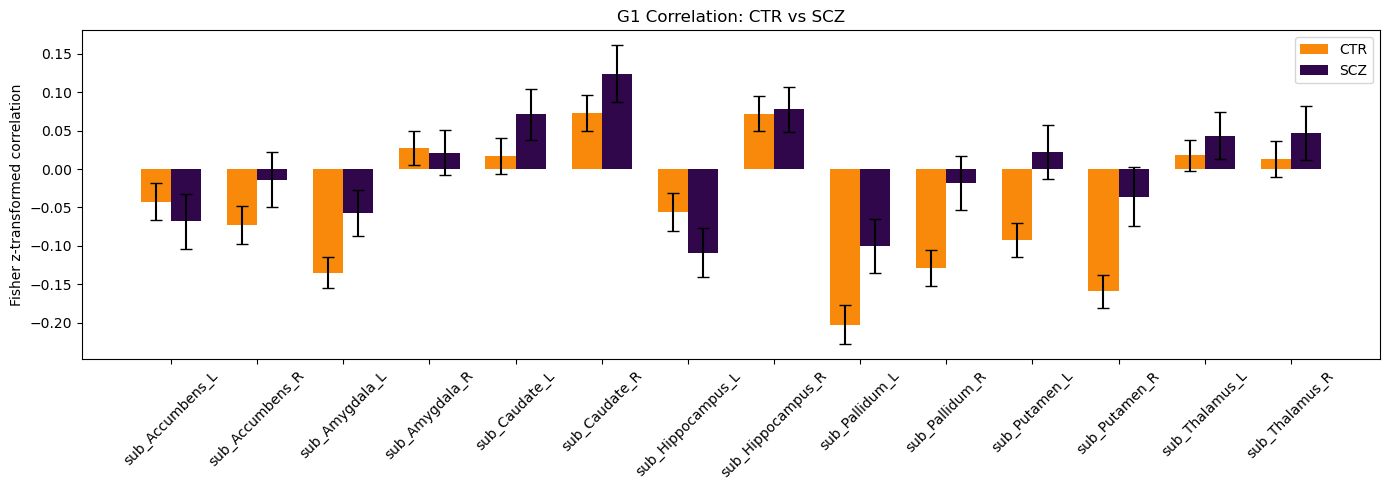

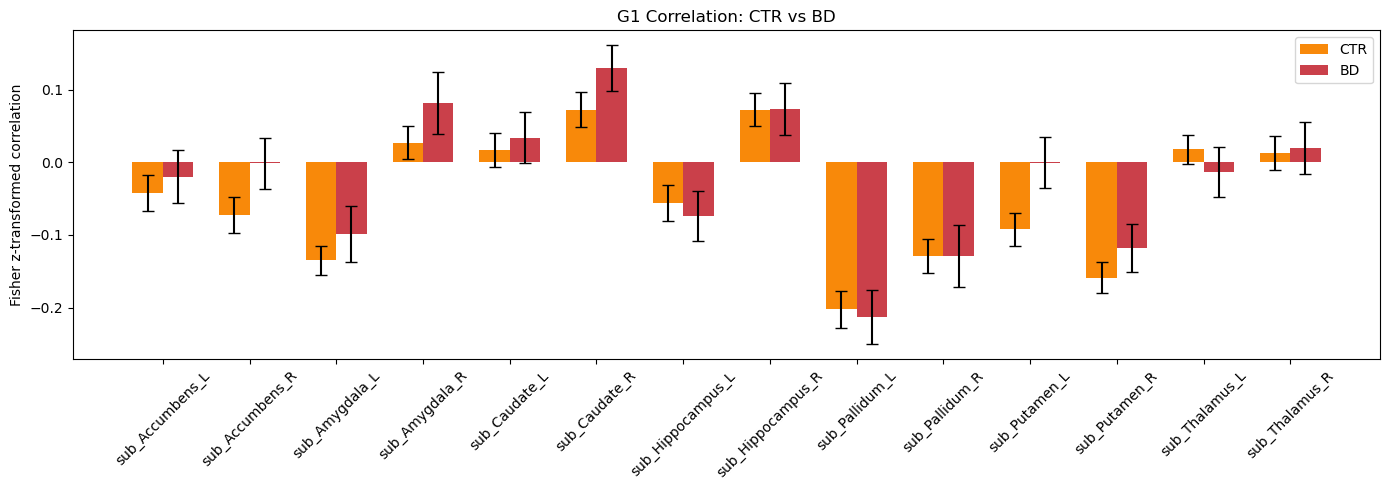

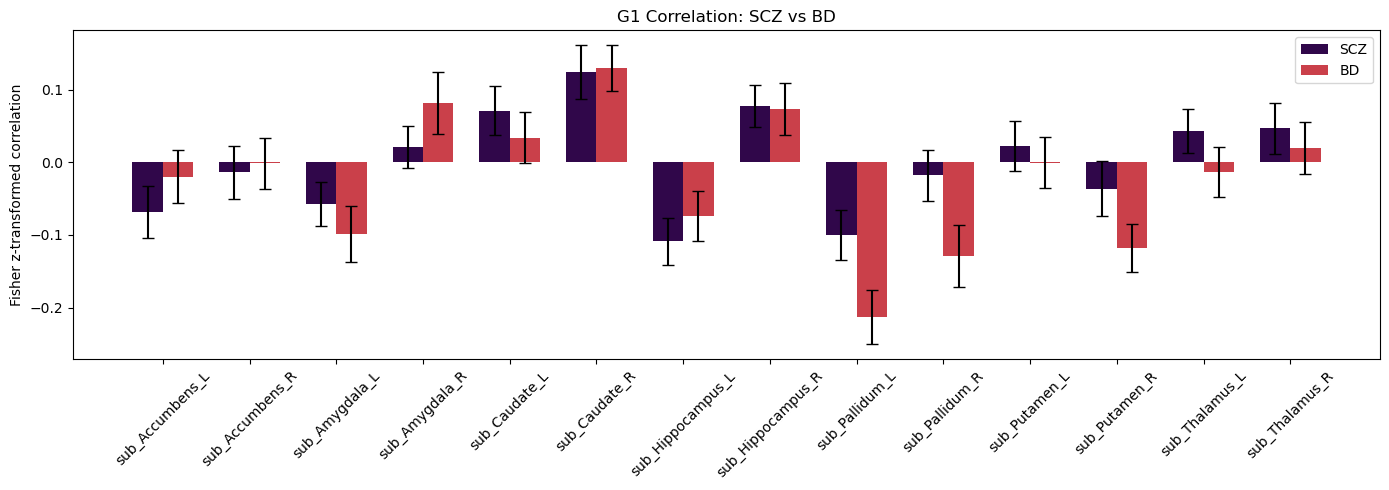

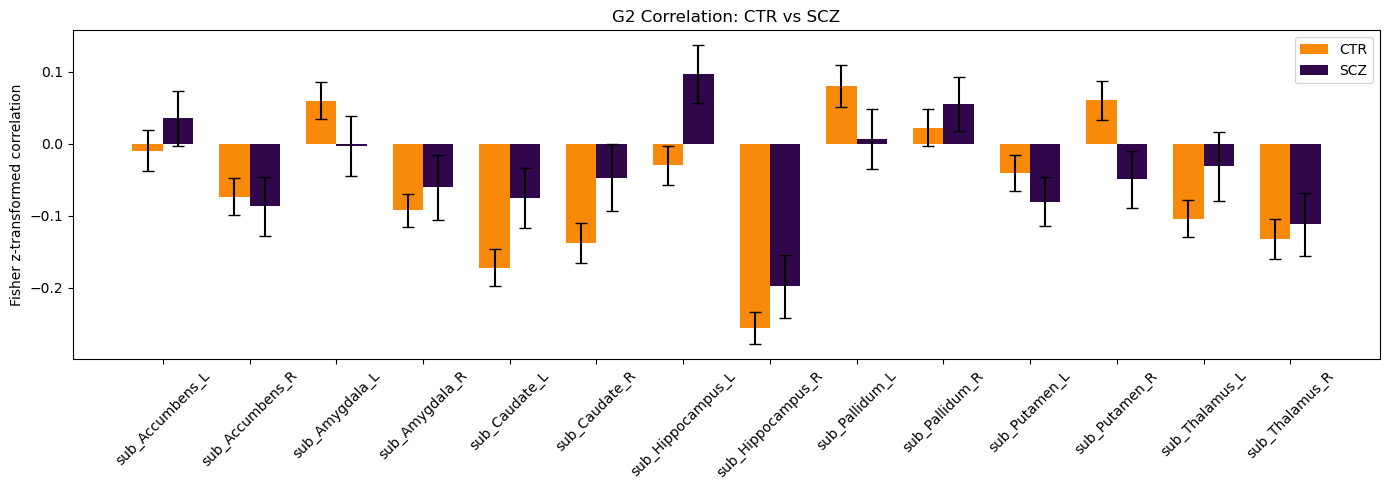

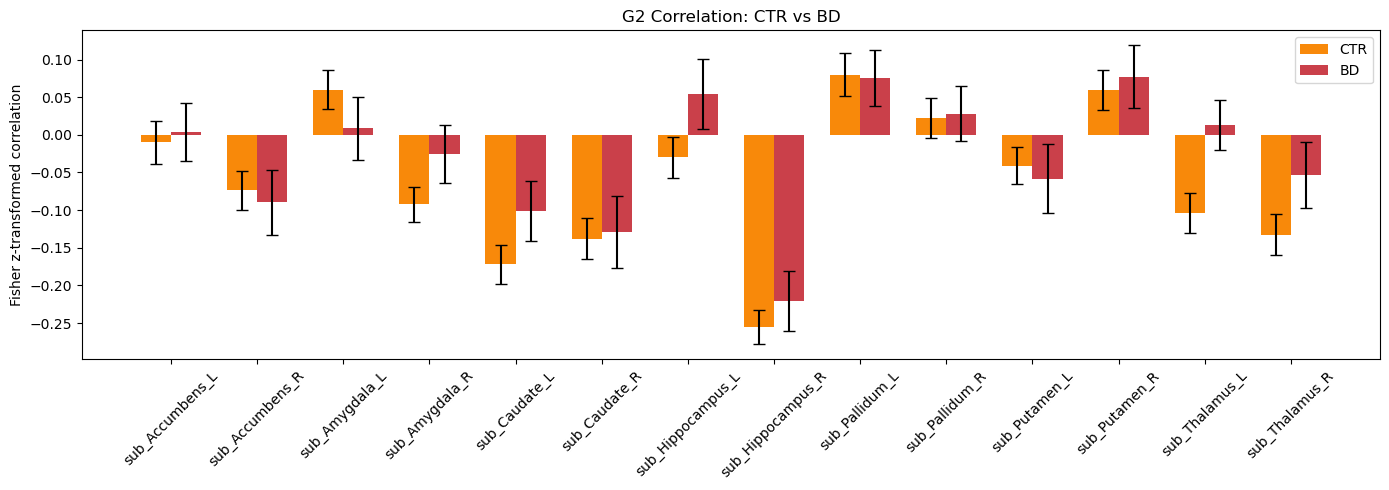

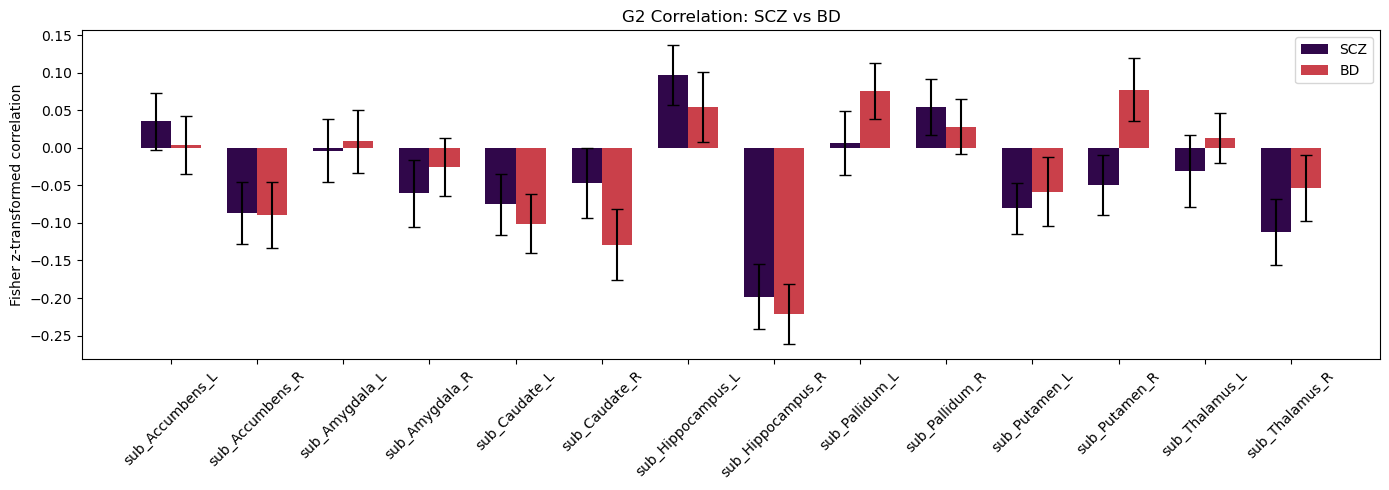

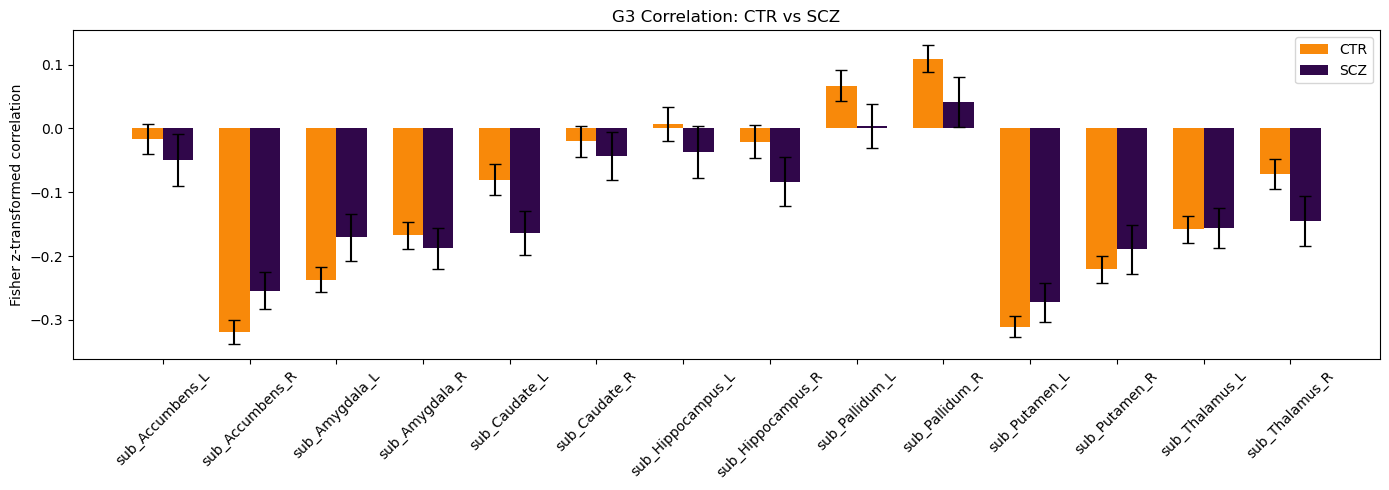

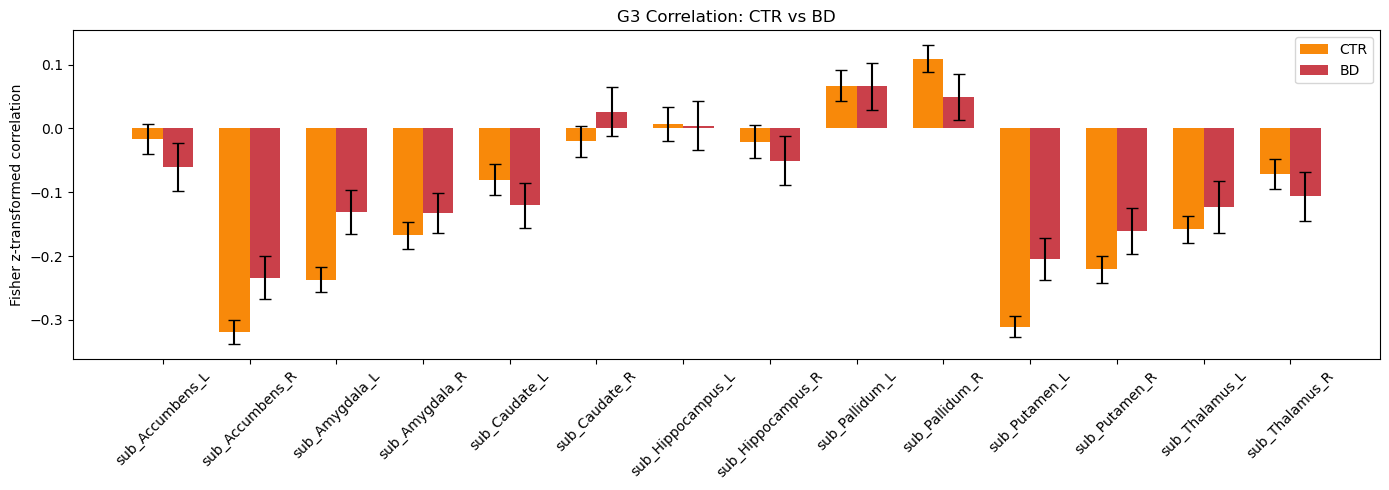

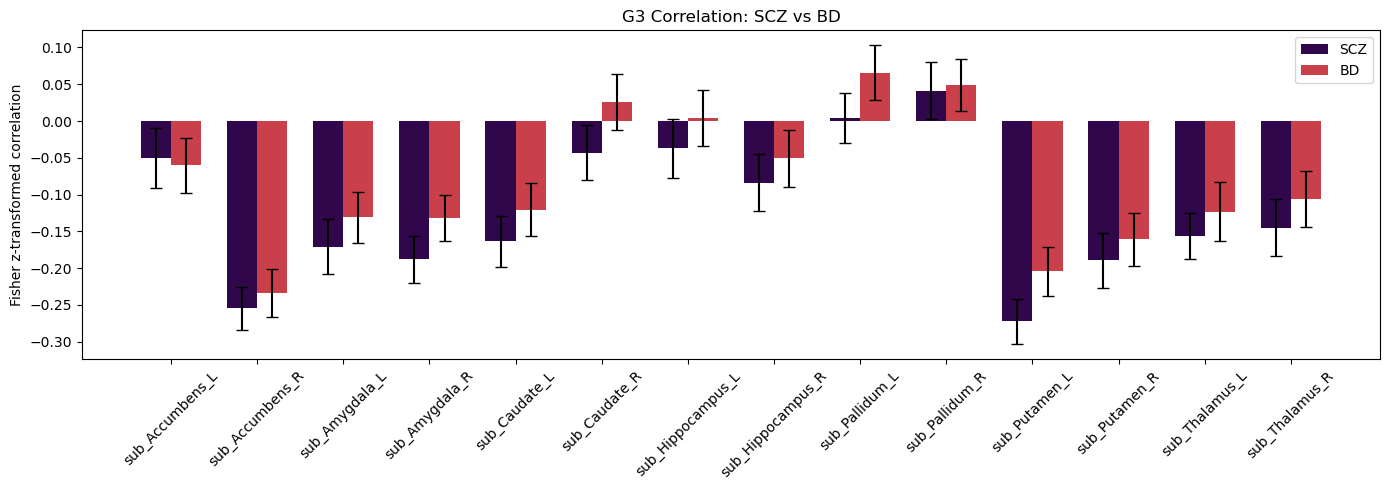

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define group colors
group_colors = {
    'SCZ': '#30074A',
    'BD':  '#CA404A',
    'CTR': '#F8890A',
    'MIX': 'gray'  # optional for MIX
}

def plot_corr_significant(embedding_dict, ttest_dict, group_labels, group_pairs):
    """
    Plots subcortical correlation embeddings for all gradients and group pairs,
    highlighting FDR-significant ROIs.
    """
    for g_name, embedding_data in embedding_dict.items():
        for g1, g2 in group_pairs:
            # Get t-test results for this pair
            ttest_df = ttest_dict[g_name][f'{g1}_vs_{g2}']

            # Identify significant ROIs
            sig_rois = ttest_df['ROI'][ttest_df['p_val_fdr'] < 0.05].tolist()

            # Prepare data for plotting
            g1_idx = [i for i, g in enumerate(group_labels) if g == g1]
            g2_idx = [i for i, g in enumerate(group_labels) if g == g2]
            data_g1 = embedding_data[g1_idx, :]
            data_g2 = embedding_data[g2_idx, :]

            # Group mean + SEM
            mean_g1 = np.mean(data_g1, axis=0)
            sem_g1  = np.std(data_g1, axis=0) / np.sqrt(data_g1.shape[0])
            mean_g2 = np.mean(data_g2, axis=0)
            sem_g2  = np.std(data_g2, axis=0) / np.sqrt(data_g2.shape[0])

            # Plot barplot with significance markers
            x = np.arange(len(subcort_regions))
            width = 0.35
            fig, ax = plt.subplots(figsize=(14,5))
            ax.bar(x - width/2, mean_g1, width, yerr=sem_g1, label=g1, capsize=4, color=group_colors.get(g1, 'lightblue'))
            ax.bar(x + width/2, mean_g2, width, yerr=sem_g2, label=g2, capsize=4, color=group_colors.get(g2, 'salmon'))

            # Highlight significant ROIs
            for i, roi in enumerate(subcort_regions):
                if roi in sig_rois:
                    # Star above bars
                    ax.text(i, max(mean_g1[i], mean_g2[i])+0.02, '*', ha='center', va='bottom', fontsize=16, color='k')
                    # Optional: light shaded background rectangle
                    ax.axvspan(i-0.5, i+0.5, color='yellow', alpha=0.1)

            ax.set_xticks(x)
            ax.set_xticklabels(subcort_regions, rotation=45)
            ax.set_ylabel('Fisher z-transformed correlation')
            ax.set_title(f'{g_name} Correlation: {g1} vs {g2}')
            ax.legend()
            plt.tight_layout()
            plt.show()

# --- Run the plotting ---
plot_corr_significant(gradients_corr, ttest_results_corr, group_labels, group_pairs)


### Plot manifolds

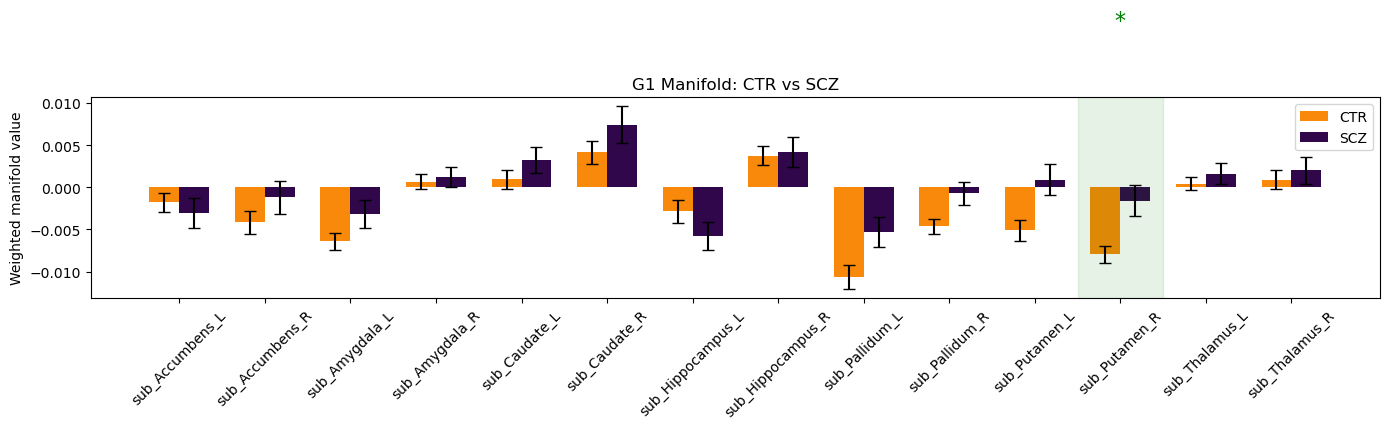

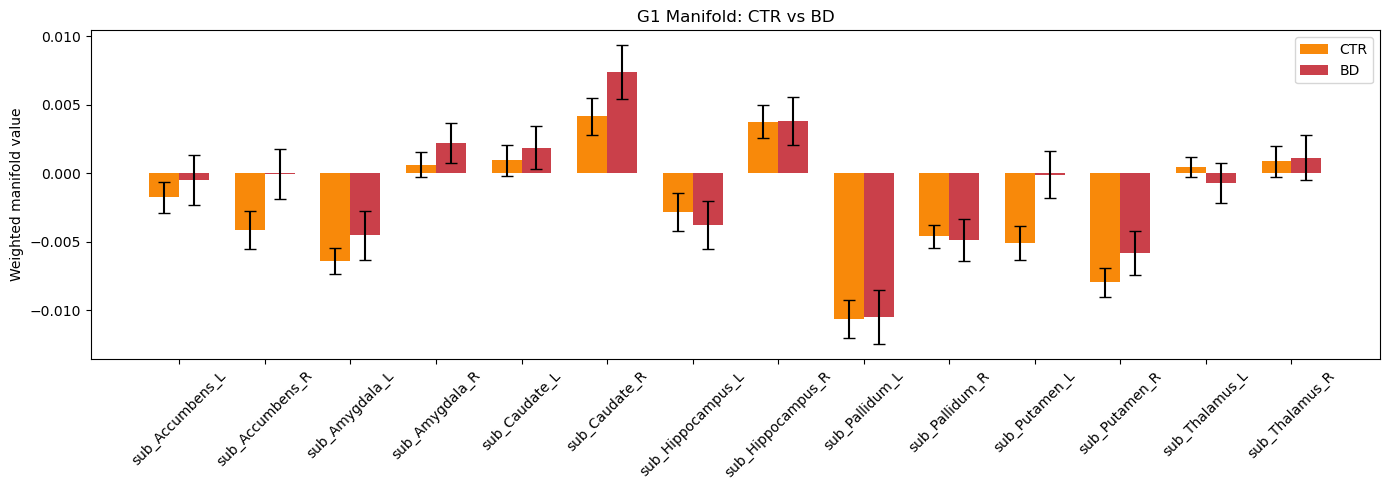

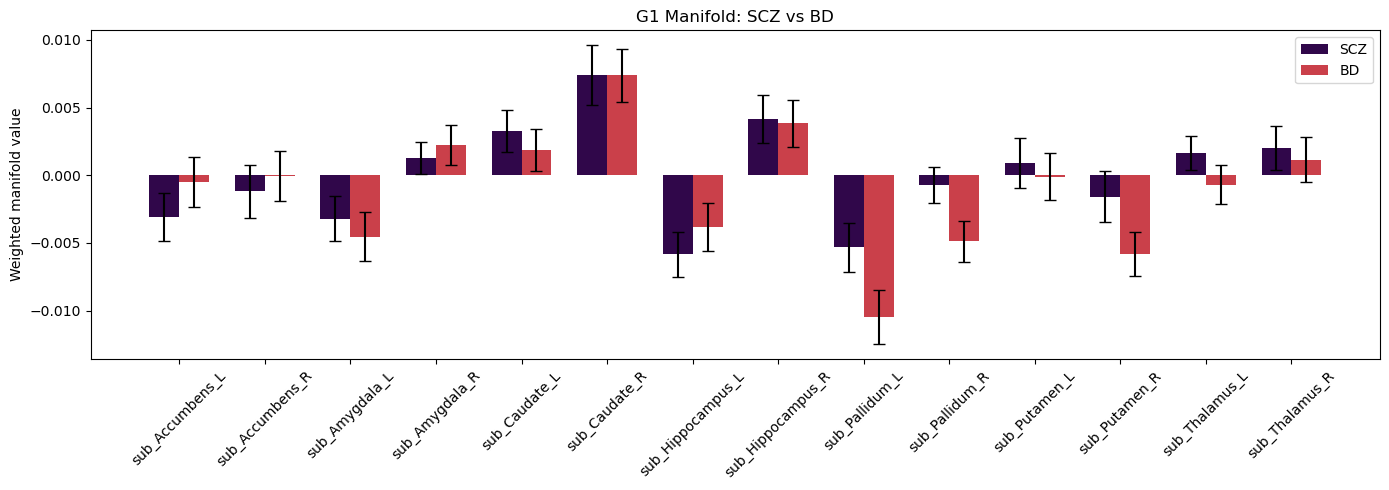

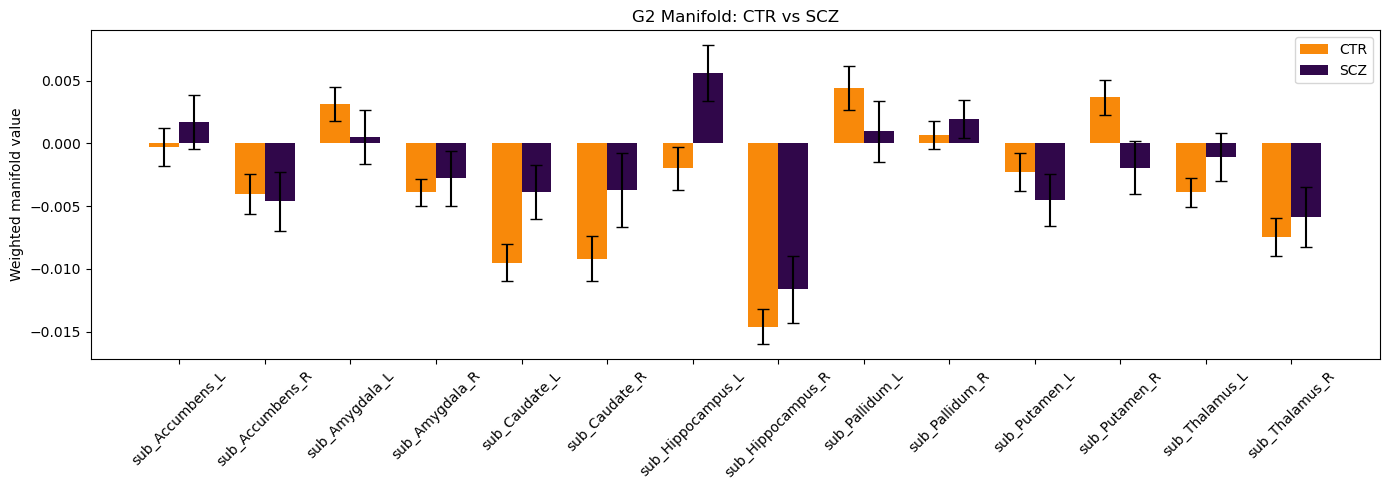

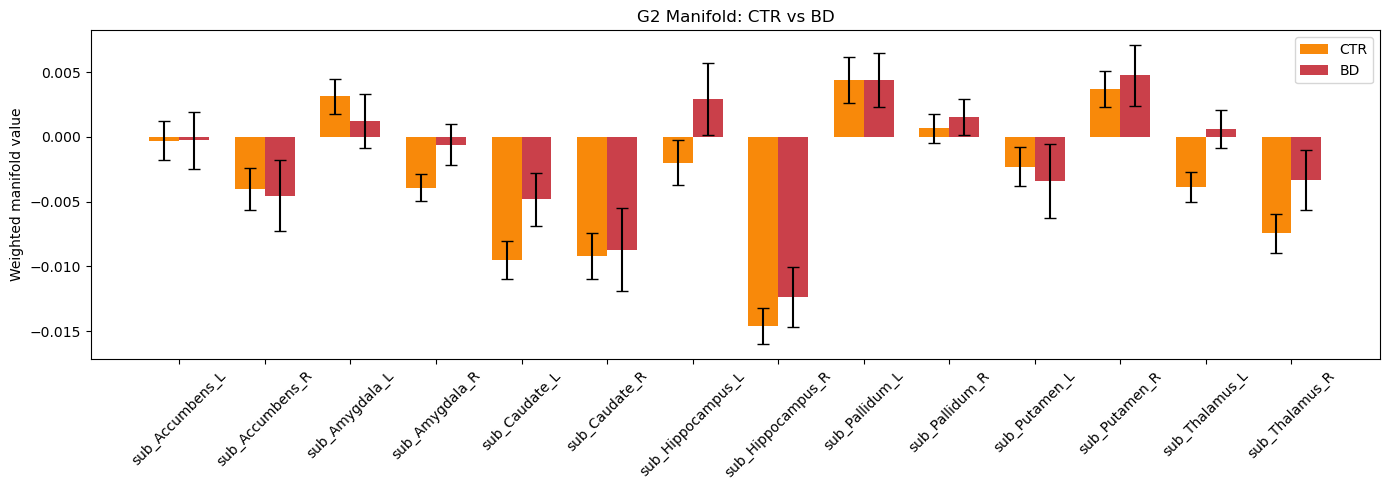

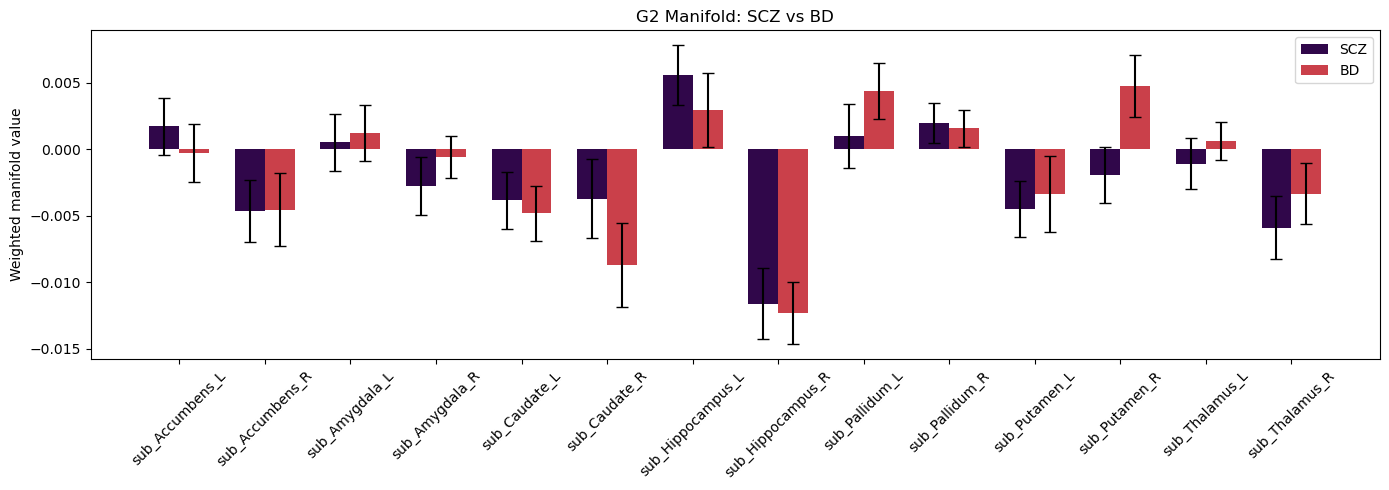

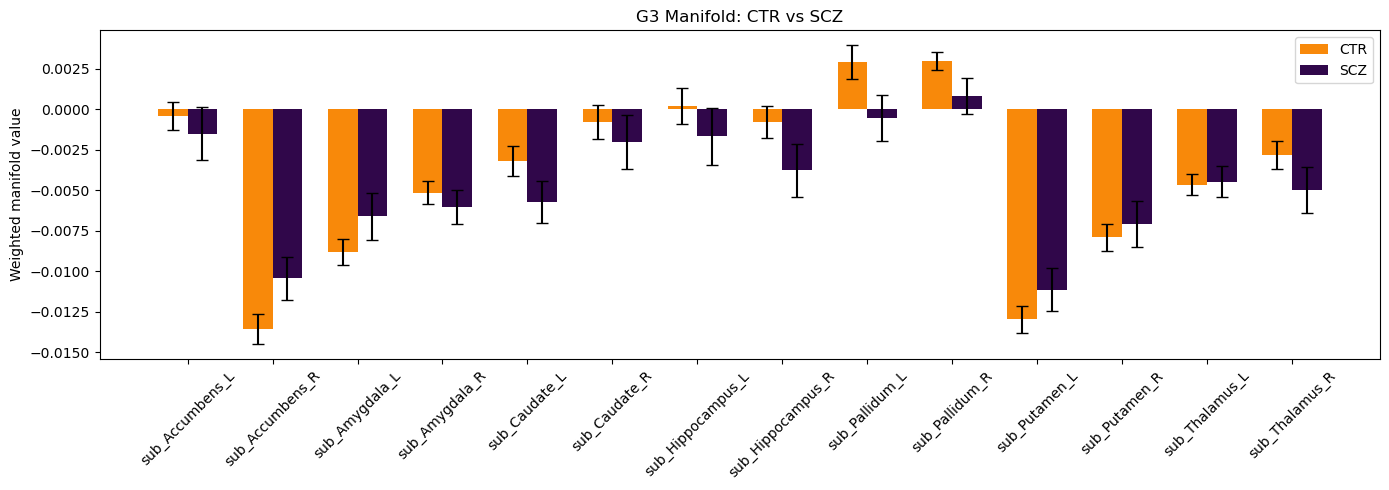

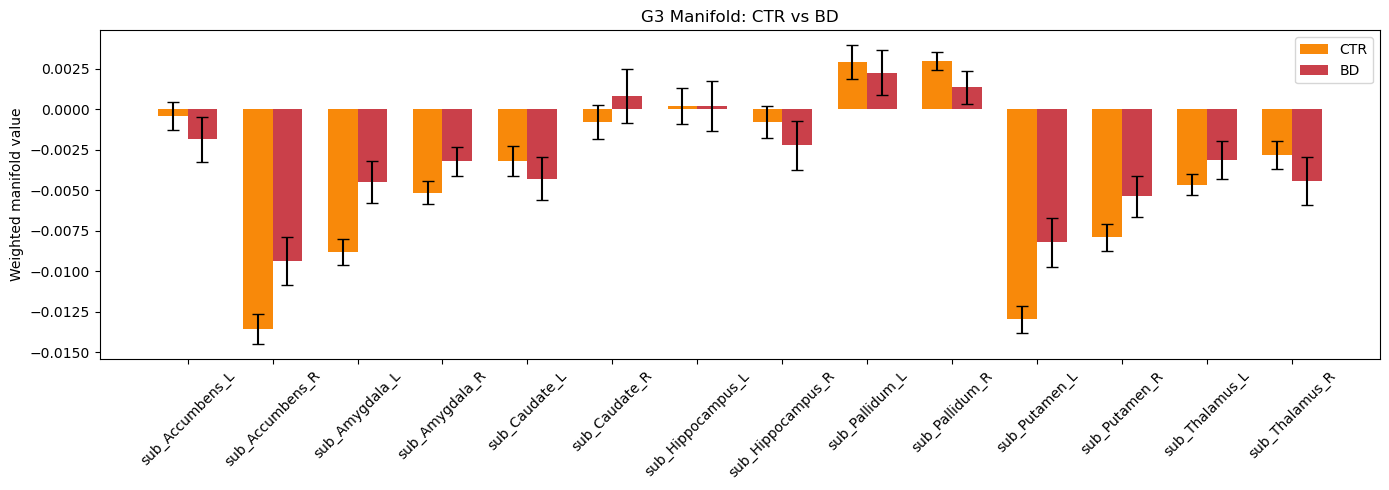

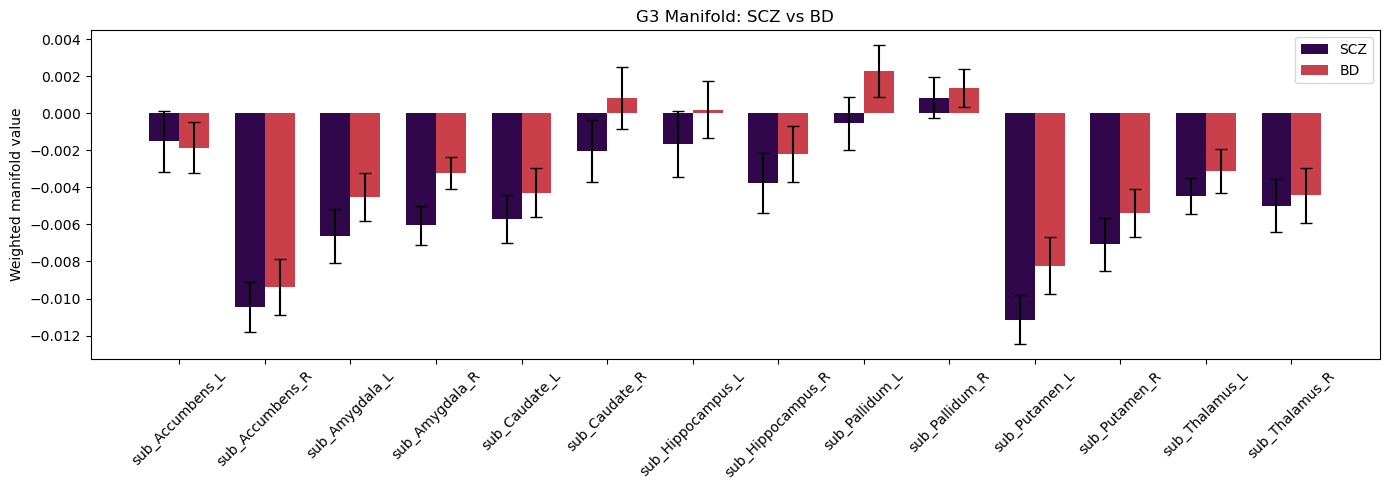

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Define group colors
group_colors = {
    'SCZ': '#30074A',
    'BD':  '#CA404A',
    'CTR': '#F8890A',
    'MIX': 'gray'  # optional for MIX
}

def plot_manifold_significant(embedding_dict, ttest_dict, group_labels, group_pairs):
    """
    Plots subcortical weighted manifold embeddings for all gradients and group pairs,
    highlighting FDR-significant ROIs in green.
    """
    for g_name, embedding_data in embedding_dict.items():
        for g1, g2 in group_pairs:
            # Get t-test results for this pair
            ttest_df = ttest_dict[g_name][f'{g1}_vs_{g2}']

            # Identify significant ROIs
            sig_rois = ttest_df['ROI'][ttest_df['p_val_fdr'] < 0.05].tolist()

            # Prepare data for plotting
            g1_idx = [i for i, g in enumerate(group_labels) if g == g1]
            g2_idx = [i for i, g in enumerate(group_labels) if g == g2]
            data_g1 = embedding_data[g1_idx, :]
            data_g2 = embedding_data[g2_idx, :]

            # Group mean + SEM
            mean_g1 = np.mean(data_g1, axis=0)
            sem_g1  = np.std(data_g1, axis=0) / np.sqrt(data_g1.shape[0])
            mean_g2 = np.mean(data_g2, axis=0)
            sem_g2  = np.std(data_g2, axis=0) / np.sqrt(data_g2.shape[0])

            # Plot barplot with significance markers
            x = np.arange(len(subcort_regions))
            width = 0.35
            fig, ax = plt.subplots(figsize=(14,5))
            ax.bar(x - width/2, mean_g1, width, yerr=sem_g1, label=g1, capsize=4, color=group_colors.get(g1, 'lightgreen'))
            ax.bar(x + width/2, mean_g2, width, yerr=sem_g2, label=g2, capsize=4, color=group_colors.get(g2, 'orange'))

            # Highlight significant ROIs in green
            for i, roi in enumerate(subcort_regions):
                if roi in sig_rois:
                    ax.text(i, max(mean_g1[i], mean_g2[i])+0.02, '*', ha='center', va='bottom', fontsize=16, color='green')
                    # Optional: light green shaded background
                    ax.axvspan(i-0.5, i+0.5, color='green', alpha=0.1)

            ax.set_xticks(x)
            ax.set_xticklabels(subcort_regions, rotation=45)
            ax.set_ylabel('Weighted manifold value')
            ax.set_title(f'{g_name} Manifold: {g1} vs {g2}')
            ax.legend()
            plt.tight_layout()
            plt.show()

# --- Run the plotting ---
plot_manifold_significant(gradients_manifold, ttest_results_manifold, group_labels, group_pairs)


# PLS with manifolds

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ------------------------
# Behavioral domains (from g1_aligned_cog)
# ------------------------
group_definitions = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward',
                                'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

other_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
              'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']

covariate_cols = ['age', 'gender']

# ------------------------
# Helper functions
# ------------------------
def ensure_numeric_encoding(df, col):
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_out(X, covariates):
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

# ------------------------
# Load behavioral CSV (aligned with cortical gradients)
# ------------------------
behavior_df = pd.read_csv('./g1_aligned_cog.csv')
behavior_df = behavior_df.rename(columns=lambda x: x.strip())  # clean column names

# Keep only BD (3) and SCZ (2)
behavior_df = behavior_df[behavior_df['diagnosis'].isin([2, 3])].copy()

# Ensure numeric encoding for categorical vars
for col in ['gender', 'diagnosis']:
    behavior_df = ensure_numeric_encoding(behavior_df, col)

# ------------------------
# Run PLS on manifold embeddings
# ------------------------
results_manifold = {}

for grad_name, X_full in gradients_manifold.items():
    print(f"\n--- Processing {grad_name} ---")

    # Convert to numpy
    X_full = np.array(X_full)

    # Align X to behavioral subjects (by index/order)
    X = X_full[behavior_df.index.values, :]

    # Behavioral domains
    for group_name, var_list in group_definitions.items():
        zscored = behavior_df[var_list].apply(lambda x: (x - x.mean())/x.std(), axis=0)
        behavior_df[group_name] = -zscored.mean(axis=1)  # invert so higher = worse

    # Combine behavioral + clinical variables (Y)
    Y_cols = other_vars + list(group_definitions.keys())
    Y = behavior_df[Y_cols].values

    # Regress out covariates from X
    covars = behavior_df[covariate_cols].values
    X_resid = regress_out(X, covars)

    # ------------------------
    # Remove subjects with missing data
    # ------------------------
    nan_rows_X = np.isnan(X_resid).any(axis=1)
    nan_rows_Y = np.isnan(Y).any(axis=1)
    valid_mask = ~(nan_rows_X | nan_rows_Y)

    X_valid = X_resid[valid_mask]
    Y_valid = Y[valid_mask]
    behavior_df_valid = behavior_df.loc[valid_mask].copy()

    # Standardize X and Y
    X_std = StandardScaler().fit_transform(X_valid)
    Y_std = StandardScaler().fit_transform(Y_valid)

    # PLS
    pls = PLSRegression(n_components=1)
    pls.fit(X_std, Y_std)

    # Extract results
    X_saliences = pls.x_weights_[:,0]
    Y_saliences = pls.y_weights_[:,0]
    X_scores = pls.x_scores_[:,0]
    Y_scores = pls.y_scores_[:,0]

    behav_corrs = {var: pearsonr(Y_std[:, i], Y_scores)[0] for i, var in enumerate(Y_cols)}

    results_manifold[grad_name] = {
        'X_scores': X_scores,
        'Y_scores': Y_scores,
        'X_saliences': X_saliences,
        'Y_saliences': Y_saliences,
        'behav_corrs': behav_corrs,
        'behavior_df': behavior_df,
        'X_std': X_std,
        'Y_std': Y_std
    }

    # Print behavioral correlations
    print(f"{grad_name} behavioral correlations:")
    for var, corr in behav_corrs.items():
        print(f"  {var:25s}: {corr:6.3f}")

print("\nPLS on manifold embeddings complete. Results stored in `results_manifold`.")



--- Processing G1 ---
G1 behavioral correlations:
  diagnosis                : -0.759
  SAPSDisorganization      :  0.498
  Amotivation              :  0.496
  DimEx                    :  0.485
  SAPSPositiveSymptoms     :  0.736
  hamilton_21              :  0.130
  YMRS                     :  0.231
  Attention_WorkingMemory  :  0.614
  VerbalLearning_Memory    :  0.618
  Reasoning_ProblemSolving :  0.651
  Verbal_Comprehension     :  0.660

--- Processing G2 ---
G2 behavioral correlations:
  diagnosis                :  0.540
  SAPSDisorganization      : -0.688
  Amotivation              : -0.832
  DimEx                    : -0.507
  SAPSPositiveSymptoms     : -0.778
  hamilton_21              : -0.482
  YMRS                     : -0.337
  Attention_WorkingMemory  : -0.304
  VerbalLearning_Memory    : -0.263
  Reasoning_ProblemSolving : -0.147
  Verbal_Comprehension     : -0.075

--- Processing G3 ---
G3 behavioral correlations:
  diagnosis                :  0.767
  SAPSDisorganizati

## Permutation testing

In [63]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# -------------------------------
# Permutation testing parameters
# -------------------------------
n_permutations = 15000  # number of permutations
n_components = 1         # LV1 only
results_perm_manifold = {}  # store permutation p-values for manifold

# Loop over gradients (G1, G2, G3)
for grad_name in results_manifold.keys():
    print(f"\nPermutation testing for manifold {grad_name}...")

    # Retrieve standardized X and Y
    X_std = results_manifold[grad_name]['X_std']  # standardized brain data
    Y_std = results_manifold[grad_name]['Y_std']  # standardized behavioral data

    # Check for NaNs and filter if necessary
    valid_mask = ~(np.isnan(X_std).any(axis=1) | np.isnan(Y_std).any(axis=1))
    X = X_std[valid_mask]
    Y = Y_std[valid_mask]

    # Fit original PLS to get observed singular value
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]
    obs_singular_value = np.cov(X_scores, Y_scores, bias=True)[0, 1]

    # -----------------------
    # Run permutations
    # -----------------------
    perm_singular_values = np.zeros(n_permutations)
    for i in range(n_permutations):
        # Shuffle rows of X
        X_perm = X[np.random.permutation(X.shape[0]), :]
        pls_perm = PLSRegression(n_components=n_components)
        pls_perm.fit(X_perm, Y)
        X_scores_perm = pls_perm.x_scores_[:, 0]
        Y_scores_perm = pls_perm.y_scores_[:, 0]
        # Compute covariance for LV1
        perm_singular_values[i] = np.cov(X_scores_perm, Y_scores_perm, bias=True)[0, 1]

    # Compute p-value: proportion of permuted covariances >= observed
    p_value = np.mean(perm_singular_values >= obs_singular_value)

    # Store results
    results_perm_manifold[grad_name] = {
        'obs_singular_value': obs_singular_value,
        'perm_singular_values': perm_singular_values,
        'p_value': p_value
    }

    print(f"{grad_name} LV1 permutation p-value: {p_value:.4f}")



Permutation testing for manifold G1...
G1 LV1 permutation p-value: 0.5333

Permutation testing for manifold G2...
G2 LV1 permutation p-value: 0.8711

Permutation testing for manifold G3...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


G3 LV1 permutation p-value: 0.6371


## Bootstrap resampling


Bootstrap resampling for manifold G1...


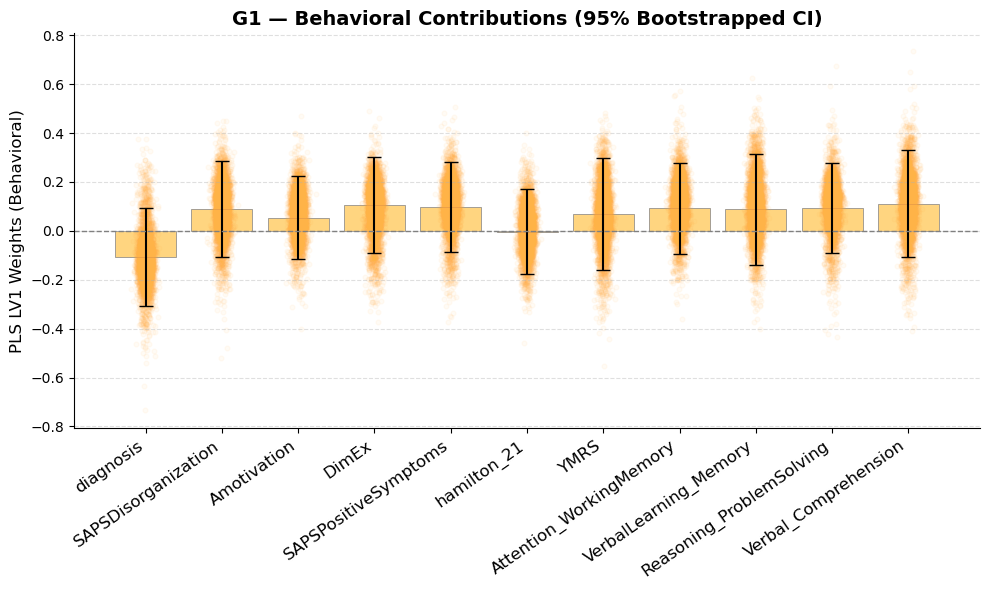


Bootstrap resampling for manifold G2...


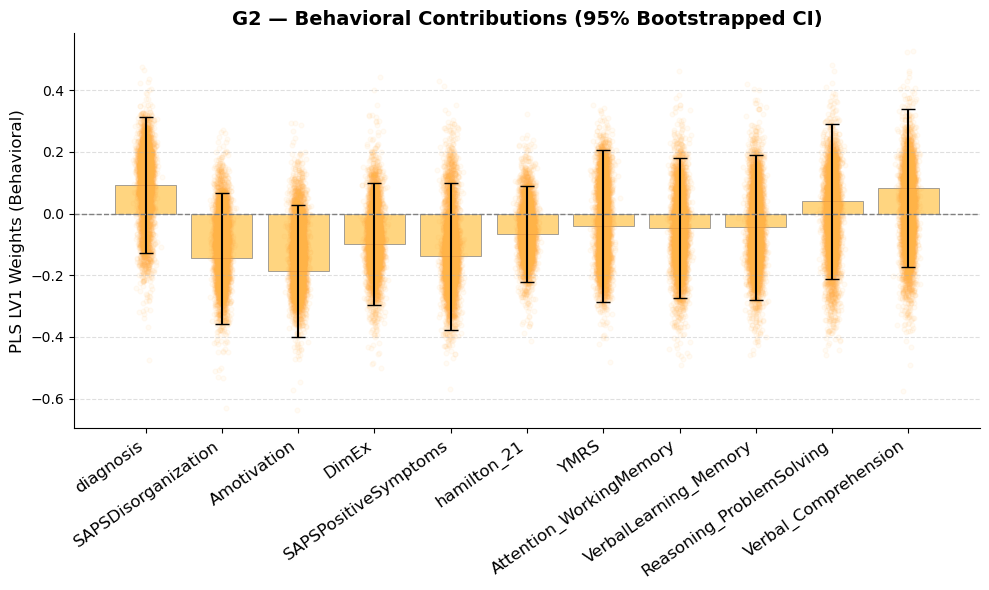


Bootstrap resampling for manifold G3...


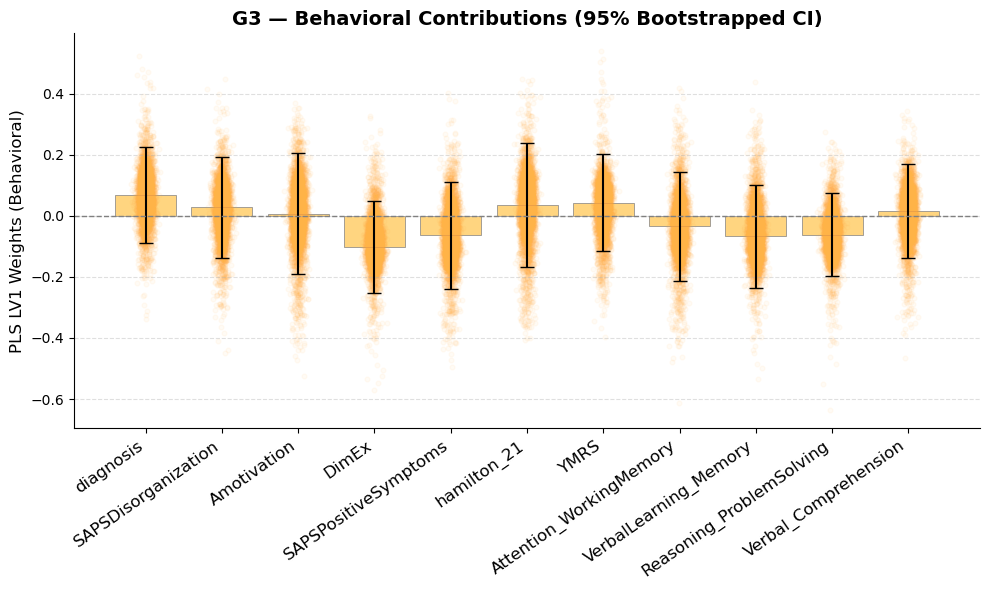

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.utils import resample

# -------------------------------
# Bootstrap parameters
# -------------------------------
n_bootstrap = 5000  # number of bootstrap resamples
n_components = 1     # LV1 only
results_boot_manifold = {}    # store bootstrap ratios

# Color palette for plotting
bar_color = '#FFD580'
point_color = '#FFB347'
star_color = 'green'  # significant bars highlighted with green stars

# -------------------------------
# Loop over gradients (manifold)
# -------------------------------
for grad_name, res in results_manifold.items():
    print(f"\nBootstrap resampling for manifold {grad_name}...")

    # Standardized X and Y
    X = res['X_std']
    Y = res['Y_std']

    # Remove subjects with NaNs
    valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
    X = X[valid_mask]
    Y = Y[valid_mask]
    n_subjects, n_voxels = X.shape
    n_behav = Y.shape[1]

    # Original PLS to get original weights
    pls_orig = PLSRegression(n_components=n_components)
    pls_orig.fit(X, Y)
    X_orig_weights = pls_orig.x_weights_[:, 0]
    Y_orig_weights = pls_orig.y_weights_[:, 0]

    # -----------------------
    # Bootstrap resampling
    # -----------------------
    X_boot_weights = np.zeros((n_bootstrap, n_voxels))
    Y_boot_weights = np.zeros((n_bootstrap, n_behav))

    for i in range(n_bootstrap):
        Xb, Yb = resample(X, Y, n_samples=n_subjects, replace=True)

        pls_boot = PLSRegression(n_components=n_components)
        pls_boot.fit(Xb, Yb)
        Xb_weights = pls_boot.x_weights_[:, 0]
        Yb_weights = pls_boot.y_weights_[:, 0]

        # Sign-flipping to align with original LV
        if np.dot(Xb_weights, X_orig_weights) < 0:
            Xb_weights *= -1
            Yb_weights *= -1

        X_boot_weights[i, :] = Xb_weights
        Y_boot_weights[i, :] = Yb_weights

    # -----------------------
    # Compute bootstrap ratios
    # -----------------------
    X_bsr = X_orig_weights / X_boot_weights.std(axis=0)
    Y_bsr = Y_orig_weights / Y_boot_weights.std(axis=0)

    results_boot_manifold[grad_name] = {
        'X_bsr': X_bsr,
        'Y_bsr': Y_bsr,
        'X_boot_weights': X_boot_weights,
        'Y_boot_weights': Y_boot_weights
    }

    # -----------------------
    # Behavioral bar plot visualization
    # -----------------------
    y_mean = Y_orig_weights
    y_sd = Y_boot_weights.std(axis=0)
    lower_ci = y_mean - 1.96 * y_sd
    upper_ci = y_mean + 1.96 * y_sd

    significant = (lower_ci > 0) | (upper_ci < 0)

    # Behavioral variable names
    Y_cols = list(res['behav_corrs'].keys())
    fig, ax = plt.subplots(figsize=(10,6))

    # Bars with error bars
    ax.bar(np.arange(n_behav), y_mean,
           width=0.8,
           yerr=[y_mean - lower_ci, upper_ci - y_mean],
           capsize=5, color=bar_color, edgecolor='gray', linewidth=0.5)

    # Overlay bootstrap points
    for j in range(n_behav):
        x = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(x, Y_boot_weights[:, j], color=point_color, alpha=0.05, s=12)

    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Significance stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                    fontsize=14, color=star_color, fontweight='bold')

    # Labels
    ax.set_xticks(np.arange(n_behav))
    ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('PLS LV1 Weights (Behavioral)', fontsize=12)
    ax.set_title(f'{grad_name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()


## Variance explained

Computing variance explained for manifold-based PLS across all gradients...

G1:
  LV1 explains 30.86% of X variance, 2.49% of Y variance, 65.23% of total X–Y cross-covariance energy, and t-u squared correlation = 8.23%

G2:
  LV1 explains 20.63% of X variance, 2.35% of Y variance, 54.78% of total X–Y cross-covariance energy, and t-u squared correlation = 10.74%

G3:
  LV1 explains 44.39% of X variance, 1.42% of Y variance, 62.78% of total X–Y cross-covariance energy, and t-u squared correlation = 7.25%



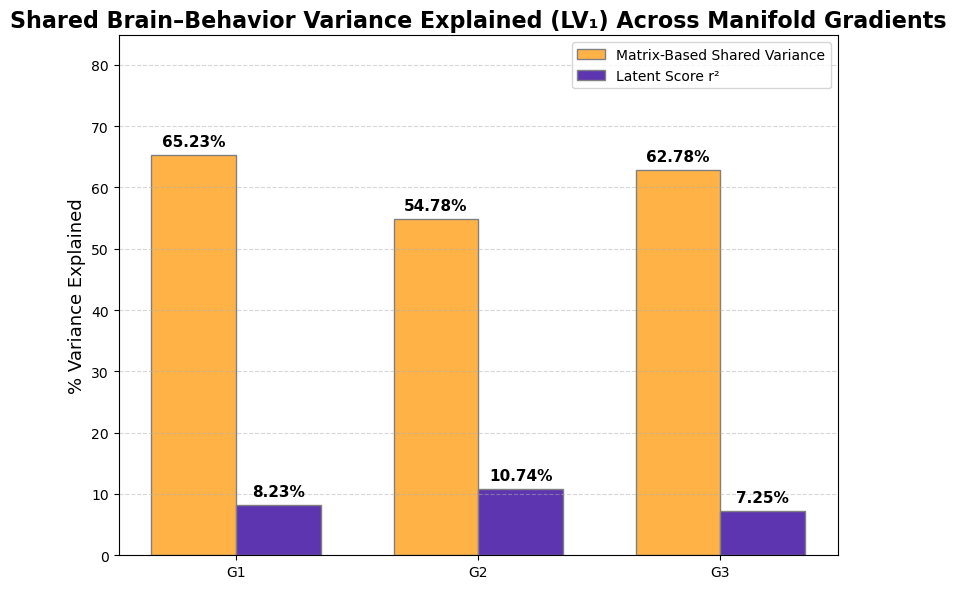

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
import os

os.makedirs("new_figures", exist_ok=True)

var_explained_manifold = {}

print("Computing variance explained for manifold-based PLS across all gradients...\n")

for grad_name, res in results_manifold.items():

    X = res['X_std']
    Y = res['Y_std']
    n_samples = X.shape[0]

    pls = PLSRegression(n_components=1)
    pls.fit(X, Y)

    # Predicted X and Y
    X_pred = pls.x_scores_ @ pls.x_loadings_.T
    Y_pred = pls.x_scores_ @ pls.y_loadings_.T

    # Variance explained
    var_X_expl = np.sum(X_pred**2) / np.sum(X**2)
    var_Y_expl = np.sum(Y_pred**2) / np.sum(Y**2)

    # Shared variance (matrix-based)
    C_full = (X.T @ Y) / (n_samples - 1)
    C_pred = (X_pred.T @ Y_pred) / (n_samples - 1)
    total_cross_energy = np.sum(C_full**2)
    explained_cross_energy = np.sum(C_pred**2)
    shared_var_matrix = 0.0 if total_cross_energy == 0 else explained_cross_energy / total_cross_energy

    # Latent score squared correlation
    t = pls.x_scores_[:, 0]
    u = pls.y_scores_[:, 0]
    r2_latent = np.corrcoef(t, u)[0, 1]**2

    # Store in results
    res['var_X_expl'] = var_X_expl
    res['var_Y_expl'] = var_Y_expl
    res['shared_var_matrix'] = shared_var_matrix
    res['r2_latent'] = r2_latent

    var_explained_manifold[grad_name] = {
        'X_var%': var_X_expl * 100,
        'Y_var%': var_Y_expl * 100,
        'Shared_matrix%': shared_var_matrix * 100,
        'r2_latent%': r2_latent * 100
    }

    print(f"{grad_name}:")
    print(f"  LV1 explains {var_X_expl*100:.2f}% of X variance, "
          f"{var_Y_expl*100:.2f}% of Y variance, "
          f"{shared_var_matrix*100:.2f}% of total X–Y cross-covariance energy, "
          f"and t-u squared correlation = {r2_latent*100:.2f}%\n")

# --- Combined plot for all gradients ---
grad_names = list(var_explained_manifold.keys())
matrix_vals = [v['Shared_matrix%'] for v in var_explained_manifold.values()]
latent_vals = [v['r2_latent%'] for v in var_explained_manifold.values()]

x = np.arange(len(grad_names))
width = 0.35  # width of the bars

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, matrix_vals, width, label='Matrix-Based Shared Variance', color='#FFB347', edgecolor='gray')
plt.bar(x + width/2, latent_vals, width, label='Latent Score r²', color='#5E35B1', edgecolor='gray')

# Add value labels
for i in range(len(grad_names)):
    plt.text(x[i] - width/2, matrix_vals[i] + 1, f"{matrix_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.text(x[i] + width/2, latent_vals[i] + 1, f"{latent_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(x, grad_names)
plt.ylabel("% Variance Explained", fontsize=13)
plt.title("Shared Brain–Behavior Variance Explained (LV₁) Across Manifold Gradients", fontsize=16, fontweight='bold')
plt.ylim(0, max(max(matrix_vals), max(latent_vals)) * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("new_figures/shared_variance_manifold_LV1.png", dpi=300)
plt.show()
